Load packages

In [183]:
from scipy import signal
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button, Cursor
from scipy import fftpack
import pandas as pd
from pathlib import Path
import os
import copy
import json
from IPython.display import display
from ipyfilechooser import FileChooser
from ephyviewer import mkQApp, MainViewer, TraceViewer
from ephyviewer import AnalogSignalSourceWithScatter
import ephyviewer
from scipy.stats import zscore
from scipy.interpolate import interp1d
from itertools import groupby
import sys 
import pickle
import seaborn as sns
from scipy.signal import find_peaks
from scipy.signal import chirp, find_peaks, peak_widths
from scipy import stats
import matplotlib.colors as mcolors
import warnings
from scipy import interpolate
import re
from scipy.stats import f_oneway
from scipy.spatial.distance import pdist, squareform
from scipy.stats import mannwhitneyu
from scipy.stats import ks_2samp
#import diptest
import random
from collections import Counter, defaultdict
import seaborn as sns
import pandas as pd
from matplotlib.colors import ListedColormap
import networkx as nx
from scipy.stats import wilcoxon
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import ast
warnings.filterwarnings("ignore")

%matplotlib widget

def count_items(x):
    if isinstance(x, str):
        s = x.strip()
        try:
            parsed = ast.literal_eval(s)
            if isinstance(parsed, (list, tuple, set)):
                return len(parsed)
        except Exception:
            pass
        s2 = re.sub(r'^[\[\(]\s*|[\]\)]\s*$', '', s)          # remove leading/trailing [] or ()
        parts = [p.strip().strip("'\"") for p in re.split(r',\s*', s2) if p.strip() != '']
        if parts:
            return len(parts)
    return 0

Select the analysis folders

In [184]:
analysisfolder0= '0_NeuronIdentity_MI_2026-04-17_13_51_23'
analysisfolder1= '1_VigSt_2026-04-22_14_36_26'
analysisfolder2= '2_OscActivity_2026-04-24_11_13_42_Deconv'
analysisfolder4= '4_Reactivation_2026-04-27_10_54_02_Ca' 
analysisfolder5= '5_OscReactivation_2026-04-27_10_39_33_Ca'

## Load neuron ID file & assign ID to each neuron

In [185]:
with open(f"/crnldata/forgetting/Aurelie/MiniscopeOE_analysis/Exploration_task/{analysisfolder0}/List_SignCells.pkl", 'rb') as pickle_file: # //10.69.168.1
    df_MazeCellID = pickle.load(pickle_file)

AllCheeseboard_cells=np.array(df_MazeCellID['all'])
HD_cells=np.array(df_MazeCellID['HD'])
PC_cells=np.array(df_MazeCellID['PC'])
PCHD_cells=np.array(df_MazeCellID['PC&HD'])
BodyMotion_cells=np.array(df_MazeCellID['BodyMouvement'])

#Spatial_cells=np.concatenate([PCHD_cells,  HD_cells, PC_cells])
Spatial_cells=np.array(df_MazeCellID['Spatial'])
Non_Spatial_cells=np.array(df_MazeCellID['NonSpatial'])

id_to_cluster = {
    p: (
        'HD' if p in HD_cells.tolist()
        else 'PC' if p in PC_cells.tolist()
        else 'PC&HD' if p in PCHD_cells.tolist()
        else 'BodyMotion' if p in BodyMotion_cells.tolist()
        else 'unclassified'
    )
    for p in AllCheeseboard_cells.tolist()
}
unclassified_cells = np.array([name for name, classification in id_to_cluster.items() if classification == 'unclassified'])


Spatial_id_to_cluster = {
    p: (
        'Spatial' if p in Spatial_cells.tolist()
        else 'Non_Spatial' if p in Non_Spatial_cells.tolist() # if p in AllCheeseboard_cells and p not in Spatial_cells.tolist()
        else 'unknown'
    )
    for p in AllCheeseboard_cells.tolist()
}

unknown_cells = np.array([name for name, classification in Spatial_id_to_cluster.items() if classification == 'unknown'])
#Non_Spatial_cells = np.array([name for name, classification in Spatial_id_to_cluster.items() if classification == 'Non_Spatial'])


## Individual activity during vigilance states

Save Vigilance State with Neuron ID

In [186]:
path1=f"/crnldata/forgetting/Aurelie/MiniscopeOE_analysis/Exploration_task/{analysisfolder1}/VigStates_Global.pkl" #//10.69.168.1
with open(path1, 'rb') as pickle_file:
    df_VigSt = pickle.load(pickle_file)

df_VigSt['Neuron_Identity'] = df_VigSt['Unit_ID'].map(id_to_cluster)
df_VigSt['Spatially_tuned'] = df_VigSt['Unit_ID'].map(Spatial_id_to_cluster)

filenameOut = Path(path1).parent / f'VigStates_Global_NeuronID.pkl'
with open(filenameOut, 'wb') as pickle_file:
    pickle.dump(df_VigSt, pickle_file)
    
filenameOut = Path(path1).parent / f'VigStates_Global_NeuronID.xlsx'
with pd.ExcelWriter(filenameOut) as writer:
    df_VigSt.to_excel(writer, index=False)

## Individual activity around oscillations per ID

Load Global Table

In [187]:
path2=f"/crnldata/forgetting/Aurelie/MiniscopeOE_analysis/Exploration_task/{analysisfolder2}/" #//10.69.168.1
with open(f"{path2}/SWR_Global.pkl", "rb") as f:
    SWR = pickle.load(f)
SWR['SWR_ID'] = SWR['Mice'] +'_'+ SWR['Session'] + '_'+ SWR['SWRNumber'].astype(str)
SWR['SWRlenght'] = SWR['SWRDuration'].apply(lambda x: 'Long' if x >= 47 else 'Short')
SWR['Neuron_Identity'] = SWR['Unit_ID'].map(id_to_cluster)
SWR['Spatially_tuned'] = SWR['Unit_ID'].map(Spatial_id_to_cluster)
SWR.to_csv(f"{path2}/SWR_Global_ID.csv", index=False)

with open(f"{path2}/Spdl_Global.pkl", "rb") as f:
    SPDL = pickle.load(f)
SPDL['Spdl_ID'] = SPDL['Mice'] +'_'+ SPDL['Session'] + '_'+ SPDL['SpdlNumber'].astype(str)
SPDL['Neuron_Identity'] = SPDL['Unit_ID'].map(id_to_cluster)
SPDL['Spatially_tuned'] = SPDL['Unit_ID'].map(Spatial_id_to_cluster)
SPDL.to_csv(f"{path2}/Spdl_Global_ID.csv", index=False)

Proportion SWRs statuts 

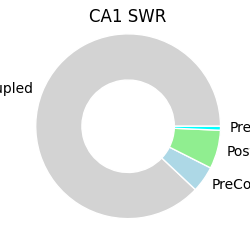

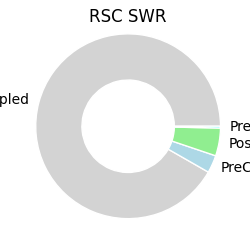

In [188]:
SWRunique= SWR.drop_duplicates(subset= 'SWR_ID', keep= 'first')
CA1SWRunique= SWRunique[SWRunique['SWRStartLocation']== 'CA1']
vals_outer= [len(CA1SWRunique[CA1SWRunique['SWRStatut']=='UnCoupled']),
             len(CA1SWRunique[CA1SWRunique['SWRStatut']=='PreCoupled']),
             len(CA1SWRunique[CA1SWRunique['SWRStatut']=='PostCoupled']),
             len(CA1SWRunique[CA1SWRunique['SWRStatut']=='PrePostCoupled'])]
size = .6
fig, ax = plt.subplots(figsize=(2.5, 2.5))
ax.pie(vals_outer, radius=1.2, labels=['UnCoupled', 'PreCoupled', 'PostCoupled', 'PrePostCoupled'], colors=['lightgrey', 'lightblue', 'lightgreen', 'cyan'],
       wedgeprops=dict(width=size, edgecolor='w'))
ax.set(aspect="equal", title= 'CA1 SWR')
plt.savefig(f'{path2}/Proportion_CA1SWR.svg', format='svg', bbox_inches='tight', pad_inches=0, transparent=True)
plt.show()

SWRunique= SWR.drop_duplicates(subset= 'SWR_ID', keep= 'first')
RSCSWRunique= SWRunique[SWRunique['SWRStartLocation']== 'RSC']
vals_outer= [len(RSCSWRunique[RSCSWRunique['SWRStatut']=='UnCoupled']),
             len(RSCSWRunique[RSCSWRunique['SWRStatut']=='PreCoupled']),
             len(RSCSWRunique[RSCSWRunique['SWRStatut']=='PostCoupled']),
             len(RSCSWRunique[RSCSWRunique['SWRStatut']=='PrePostCoupled'])]
fig, ax = plt.subplots(figsize=(2.5,2.5))
ax.pie(vals_outer, radius=1.2, labels=['UnCoupled', 'PreCoupled', 'PostCoupled', 'PrePostCoupled'], colors=['lightgrey', 'lightblue', 'lightgreen', 'cyan'],
       wedgeprops=dict(width=size, edgecolor='w'))
ax.set(aspect="equal", title= 'RSC SWR')
plt.savefig(f'{path2}/Proportion_RSCSWR.svg', format='svg', bbox_inches='tight', pad_inches=0, transparent=True)
plt.show()

Load PSTHs

In [189]:
Oscillations={'Spdl', 'SWR'}
Oscillations={'SWR'}

Data='Ca'
Coupling=''
save = 1

for Osc in Oscillations:
    if Osc == 'SWR':
        Ctx= {'CA1', 'RSC','CA1RSC'}
    elif Osc == 'Spdl': 
        Ctx= {'S1', 'PFC','S1PFC'}
    for ctx in Ctx:
        filename=f"{path2}/{Osc}_{Data}PSTH_{Coupling}{ctx}.pkl"
        with open(filename, 'rb') as pickle_file:
            locals()[f'{Osc}_{ctx}'] = dict(pickle.load(pickle_file))

In [190]:
dicts = [SWR_CA1, SWR_CA1RSC]  # list of dicts
# all keys that appear in ANY dictionary
all_keys = set().union(*dicts)

result = {}
for k in all_keys:
    arrays = [d[k] for d in dicts if k in d]   # use only existing values
    result[k] = np.concatenate(arrays, axis=0)
SWR_CA1 = result

SWR


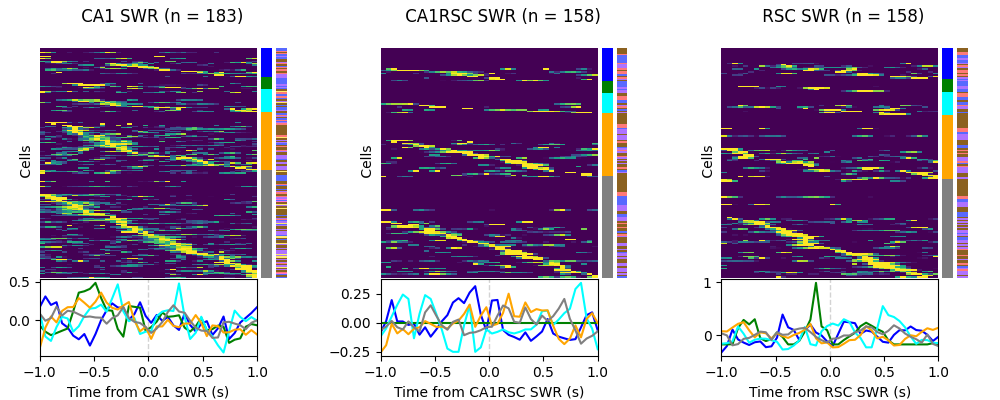

In [191]:
label_colors = {'HD': 'blue', 'PC&HD': 'green', 'PC': 'cyan', 'BodyMotion': 'orange', 'unclassified': 'grey'}
label_colors2 = {'BrC': "#8B6120FF", 'PC': "#AF72FFFF", 'BC': "#5869FFFF", 'RC': "#FF7979FF", 'RL':"#FF6FD4FD", 'YL': "#FFE96EFF"}

window = [-1, 1]  # from -10s to +10s around each event
bin_width = 1/20
bins = np.arange(window[0], window[1] + bin_width, bin_width)

for Osc in Oscillations:
    if Osc == 'SWR':
        Ctx= {'CA1', 'RSC','CA1RSC'}
    elif Osc == 'Spdl': 
        Ctx= {'S1', 'PFC','S1PFC'}
        
    fig = plt.figure(figsize=(10, 4))    
    subfigs = fig.subfigures(1, len(Ctx), wspace=0.07, hspace=0)
    print(Osc)

    for subplotnb, subfig in enumerate(subfigs.flat, start=1):
        ctx=list(Ctx)[subplotnb-1]     
        
        PSTH = locals()[f'{Osc}_{ctx}']
        PSTH_filt = {k: v for k, v in PSTH.items() if k in df_VigSt['Unit_ID'].values}
        PSTH_filt_baselined = {key: data - np.nanmean(data[:, :data.shape[1] // 4], axis=1)[:, None] for key, data in PSTH_filt.items()}
        #data = np.array([np.nanmean(zscore(PSTH_filt_norm[key], axis=1), axis= 0) for key in PSTH_filt_norm.keys()])
        data = np.array([np.nanmean(PSTH_filt_baselined[key], axis= 0) for key in PSTH_filt_baselined.keys()])
        psth_df = pd.DataFrame(data.T, columns = list(PSTH_filt_baselined.keys()))
        
        # identify cell identity
        psth_df = psth_df.T
        psth_df['Unit_ID']=psth_df.index
        psth_df = pd.merge(psth_df, df_VigSt[['Unit_ID', 'Mice', 'Neuron_Identity']].drop_duplicates(), on='Unit_ID', how='outer')
        psth_df["Neuron_Identity"] = psth_df["Neuron_Identity"].str.replace("_", "", regex=False)
        psth_df.index=  psth_df["Mice"] + "_" + psth_df["Unit_ID"] + "_" + psth_df["Neuron_Identity"]
        psth_df = psth_df.drop(["Unit_ID", "Neuron_Identity", "Mice"], axis=1)
        
        psth_df = psth_df.dropna(how='any') # remove cells not recorded during oscillations
        psth_df = psth_df[psth_df.index.str.split('_').str[-1] != 'unclassified'] if 'unclassified' not in label_colors.keys() else psth_df
        psth_df = psth_df[psth_df.index.str.split('_').str[-1] != 'nan']
        psth_df = psth_df[~psth_df.index.isna()]

        # normalize each row
        psth_df_n = psth_df.divide(psth_df.max(axis=1), axis='index') 
        psth_df_n = zscore(psth_df, axis=1)
        psth_df_n = psth_df_n.replace(np.nan, 0)
        
        # or do not normalize
        #psth_df_n = psth_df.replace(np.nan, 0)

        # sort by max activity position & sort by identity
        max_col_pos = psth_df_n.values.argmax(axis=1)
        psth_df_n['max_col_pos']= max_col_pos    
        order_map = {v: i for i, v in enumerate(label_colors.keys())}
        psth_df_n["neuronID"] =[str(idx).split('_')[-1] for idx in psth_df_n.index.tolist()]
        psth_df_n["neuronID"] = psth_df_n["neuronID"].map(order_map)
        df = psth_df_n.sort_values(["neuronID", "max_col_pos"]).drop(columns="max_col_pos").drop(columns="neuronID")

        if len(df)>0:

            gs = subfig.add_gridspec(nrows=2, ncols=3, height_ratios=[3, 1],   width_ratios=[10, 0.5, 0.5], hspace=0.01, wspace=0.05 )

            row_labels = df.index.str.split('_').str[-1]
            color_codes = [list(label_colors).index(lbl) for lbl in row_labels]
            color_array = np.array(color_codes).reshape(-1, 1)
            cmap1 = ListedColormap([label_colors[k] for k in label_colors])
            
            row_labels2 = df.index.str.split('_').str[0]
            color_codes2 = [list(label_colors2).index(lbl) for lbl in row_labels2]
            color_array2 = np.array(color_codes2).reshape(-1, 1)
            cmap2 = ListedColormap([label_colors2[k] for k in label_colors2])

            ax_heatmap = subfig.add_subplot(gs[0, 0])
            sns.heatmap(df, ax=ax_heatmap, cmap="viridis", cbar=False, cbar_kws={'location': 'top'}, yticklabels=False, vmin=-.0, vmax=2)
            ax_heatmap.set_yticklabels([]) 
            ax_heatmap.set_xticks([])
            ax_heatmap.set_ylabel(f" Cells")  
            ax_heatmap.collections[0].set_rasterized(True) if save else None
            
            ax_ann = subfig.add_subplot(gs[0, 1])
            sns.heatmap(color_array, ax=ax_ann, cmap=cmap1, cbar=False, vmin=0, vmax=len(label_colors) - 1)
            ax_ann.set_xticks([])
            ax_ann.set_yticks([])
            ax_ann.tick_params(left=False, right=False)       

            ax_ann2 = subfig.add_subplot(gs[0, 2])
            sns.heatmap(color_array2, ax=ax_ann2, cmap=cmap2, cbar=False, vmin=0, vmax=len(label_colors2) - 1)
            ax_ann2.set_xticks([])
            ax_ann2.set_yticks([])
            ax_ann2.tick_params(left=False, right=False) 

            time_bins = np.linspace(window[0], window[1], len(bins)-1)
            ax_bottom = subfig.add_subplot(gs[1, 0])  # span both columns
            #ax_bottom.plot(time_bins, zscore(np.mean(df, axis=0)), color='black')
            ax_bottom.axvline(x=0, color='lightgrey', linestyle='--', linewidth=1)
            for label in label_colors.keys():
                df_a = df[df.index.str.split('_').str[-1] == label]
                ax_bottom.plot(time_bins, (np.mean(df_a, axis=0)), color=label_colors[label])
            ax_bottom.set_xlabel(f"Time from {ctx} {Osc} (s)")
            ax_bottom.set_xlim(window[0], window[1])
            #ax_bottom.set_ylim(-.5, .5)

            subfig.suptitle(f'{Coupling} {ctx} {Osc} (n = {len(df)})')
    plt.tight_layout()
    plt.savefig(f'{Path(path2)}/AllCell_NeuronID_RSheatmap&traces_{Coupling}{Osc}.svg', format='svg', bbox_inches='tight', pad_inches=0, transparent=True) if save else None
    plt.show()

## Cell assembly reactivation during vigilance states

In [192]:
path4=f"/crnldata/forgetting/Aurelie/MiniscopeOE_analysis/Exploration_task/{analysisfolder4}/CellAssembly_Global.pkl" #//10.69.168.1
with open(path4, 'rb') as pickle_file:
    df_CellAss_origin = pickle.load(pickle_file)

drug= 'baseline'
NrSubtype='L2_3_mice' # L1NDNF_mice OR L2_3_mice
min_cell_ass_size = 2

Plot Cell assembly activity relative to Vig States

0 / 1276 cell assembly reactivation removed because from different session date than their recording session
66/296 cell assemblies contained less than 2 neurons
WilcoxonResult(statistic=nan, pvalue=nan)


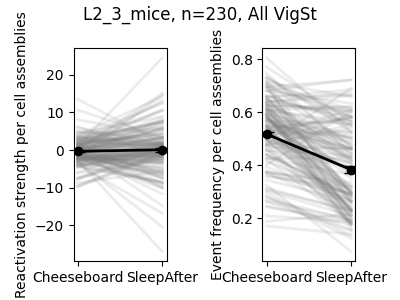

WilcoxonResult(statistic=nan, pvalue=nan)


In [193]:
df_CellAss_origin = df_CellAss_origin[df_CellAss_origin['SubstateDuration'] != 0]

initial_nb= df_CellAss_origin['Assembly_ID'].nunique()

# keep cell assemblies with a minimum of neurons
df_CellAss_origin = df_CellAss_origin[df_CellAss_origin['Assembly_size'] >= min_cell_ass_size]

# remove if none of the sign cells are in the reactivation 

mask = df_CellAss_origin["Cells_in_Assembly_in_rec"].apply(lambda x: not any(ast.literal_eval(x)))
df_CellAss_origin=df_CellAss_origin[~mask]
"""
# remove if not all sign cells are in the reactivation 
mask = df_CellAss_origin["Cells_in_Assembly_in_rec"].apply(lambda x: all(ast.literal_eval(x)))
df_CellAss_origin=df_CellAss_origin[mask]
"""

# keep only cell assemblies from the same session date as their recording session
A=len( df_CellAss_origin)
df_CellAss_origin['Assembly_ID_sess'] = df_CellAss_origin['Assembly_ID'].str.rsplit('_', n=1).str[0]
Corr_df=df_CellAss_origin.explode("Assembly_ID_sess")[['Session_Date', 'Session']].drop_duplicates()
df_CellAss_origin['Cell_assembly_Date'] = df_CellAss_origin['Assembly_ID_sess'].map(Corr_df.set_index('Session')['Session_Date'])
df_CellAss_origin = df_CellAss_origin[df_CellAss_origin['Cell_assembly_Date'] == df_CellAss_origin['Session_Date']]
B=len( df_CellAss_origin)

print(A-B,'/',A, 'cell assembly reactivation removed because from different session date than their recording session')

df_CellAss=df_CellAss_origin.copy()

print(f"{initial_nb - df_CellAss['Assembly_ID'].nunique()}/{initial_nb} cell assemblies contained less than {min_cell_ass_size} neurons")

# Convert string representations of lists into actual Python lists.
df_CellAss['Cells_in_Assembly']=df_CellAss['Cells_in_Assembly'] = df_CellAss['Cells_in_Assembly'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
# Filter the DataFrame to only keep rows where the number of cells in the list matches the 'Assembly_size'.
df_CellAss = df_CellAss[df_CellAss['Cells_in_Assembly'].apply(len) == df_CellAss['Assembly_size']]

plt.figure(figsize=(4, 3))
table_CellAss = df_CellAss.pivot_table(index='Assembly_ID', columns=[df_CellAss['ExpeType']], values='Avg_ReactStr', aggfunc='mean', fill_value=None)
desired_order = ['Cheeseboard','SleepAfter']   
try: table_CellAss = table_CellAss[desired_order]
except: pass
plt.subplot(1,2,1)
plt.plot(table_CellAss.columns, table_CellAss.values.T, color= 'grey', alpha=0.15, linewidth=2)
plt.plot(table_CellAss.columns, table_CellAss.mean(), linewidth=2, color='black')
plt.errorbar(table_CellAss.columns, table_CellAss.mean(), yerr=table_CellAss.sem() ,
             fmt='o', color='black', capsize=5)
plt.ylabel('Reactivation strength per cell assemblies')

stats.shapiro(table_CellAss['Cheeseboard'])
stats.shapiro(table_CellAss['SleepAfter'])
res= wilcoxon(table_CellAss['Cheeseboard'], table_CellAss['SleepAfter'])
print(res)

table_CellAss2 = df_CellAss.pivot_table(index='Assembly_ID', columns=[df_CellAss['ExpeType']], values='EventFreq', aggfunc='mean', fill_value=None)
try: table_CellAss2 = table_CellAss2[desired_order]
except: pass
plt.subplot(1,2,2)
plt.plot(table_CellAss2.columns, table_CellAss2.values.T, color= 'grey', alpha=0.15, linewidth=2)
plt.plot(table_CellAss2.columns, table_CellAss2.mean(), linewidth=2, color='black')
plt.errorbar(table_CellAss2.columns, table_CellAss2.mean(), yerr=table_CellAss2.sem() ,
            fmt='o', color='black', capsize=5)
plt.ylabel('Event frequency per cell assemblies')
plt.suptitle(f'{NrSubtype}, n={len(table_CellAss)}, All VigSt')
plt.tight_layout()
plt.savefig(f'{Path(path4).parent}/CellAssembly_MazeVSPost.svg', format='svg', bbox_inches='tight', pad_inches=0, transparent=True)
plt.show()

stats.shapiro(table_CellAss2['Cheeseboard'])
stats.shapiro(table_CellAss2['SleepAfter'])
res= wilcoxon(table_CellAss2['Cheeseboard'], table_CellAss2['SleepAfter'])
print(res)

WilcoxonResult(statistic=nan, pvalue=nan)


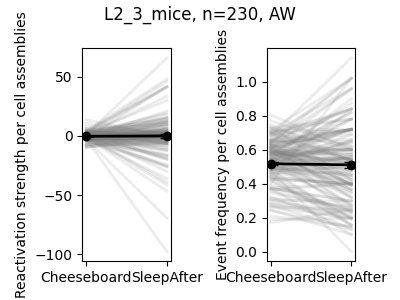

WilcoxonResult(statistic=nan, pvalue=nan)


In [194]:
df_CellAss=df_CellAss_origin.copy()
df_CellAss = df_CellAss[df_CellAss['SubstateDuration'] != 0]

df_CellAss = df_CellAss[df_CellAss['Substate']=='AW']

# Convert string representations of lists into actual Python lists.
df_CellAss['Cells_in_Assembly']=df_CellAss['Cells_in_Assembly'] = df_CellAss['Cells_in_Assembly'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
# Filter the DataFrame to only keep rows where the number of cells in the list matches the 'Assembly_size'.
df_CellAss = df_CellAss[df_CellAss['Cells_in_Assembly'].apply(len) == df_CellAss['Assembly_size']]

plt.figure(figsize=(4, 3))
table_CellAss = df_CellAss.pivot_table(index='Assembly_ID', columns=[df_CellAss['ExpeType']], values='Avg_ReactStr', aggfunc='mean', fill_value=None)
desired_order = ['Cheeseboard','SleepAfter']   
try: table_CellAss = table_CellAss[desired_order]
except: pass
plt.subplot(1,2,1)
plt.plot(table_CellAss.columns, table_CellAss.values.T, color= 'grey', alpha=0.15, linewidth=2)
plt.plot(table_CellAss.columns, table_CellAss.mean(), linewidth=2, color='black')
plt.errorbar(table_CellAss.columns, table_CellAss.mean(), yerr=table_CellAss.sem() ,
             fmt='o', color='black', capsize=5)
plt.ylabel('Reactivation strength per cell assemblies')

stats.shapiro(table_CellAss['Cheeseboard'])
stats.shapiro(table_CellAss['SleepAfter'])
res= wilcoxon(table_CellAss['Cheeseboard'], table_CellAss['SleepAfter'])
print(res)

table_CellAss2 = df_CellAss.pivot_table(index='Assembly_ID', columns=[df_CellAss['ExpeType']], values='EventFreq', aggfunc='mean', fill_value=None)
try: table_CellAss2 = table_CellAss2[desired_order]
except: pass
plt.subplot(1,2,2)
plt.plot(table_CellAss2.columns, table_CellAss2.values.T, color= 'grey', alpha=0.15, linewidth=2)
plt.plot(table_CellAss2.columns, table_CellAss2.mean(), linewidth=2, color='black')
plt.errorbar(table_CellAss2.columns, table_CellAss2.mean(), yerr=table_CellAss2.sem() ,
            fmt='o', color='black', capsize=5)
plt.ylabel('Event frequency per cell assemblies')
plt.suptitle(f'{NrSubtype}, n={len(table_CellAss)}, AW')
plt.tight_layout()
plt.savefig(f'{Path(path4).parent}/CellAssembly_AWMazeVSAWPost.svg', format='svg', bbox_inches='tight', pad_inches=0, transparent=True)
plt.show()

stats.shapiro(table_CellAss2['Cheeseboard'])
stats.shapiro(table_CellAss2['SleepAfter'])
res= wilcoxon(table_CellAss2['Cheeseboard'], table_CellAss2['SleepAfter'])
print(res)

ANOVA result: F = 0.019, p = 9.964e-01
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    AW   NREM   0.0921 0.9999 -3.3635 3.5478  False
    AW     QW   0.3131 0.9955 -3.1425 3.7688  False
    AW    REM   0.1286 0.9997 -3.3508  3.608  False
  NREM     QW    0.221 0.9984 -3.2346 3.6766  False
  NREM    REM   0.0365    1.0 -3.4429 3.5158  False
    QW    REM  -0.1845 0.9991 -3.6639 3.2948  False
---------------------------------------------------
ANOVA result: F = 81.636, p = 3.667e-44
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
    AW   NREM  -0.2773    0.0 -0.3344 -0.2202   True
    AW     QW  -0.2142    0.0 -0.2714 -0.1571   True
    AW    REM  -0.0075 0.9867 -0.0651    0.05  False
  NREM     QW    0.063 0.0238  0.0059  0.1202   True
  NREM    REM   0.2697    0.0 

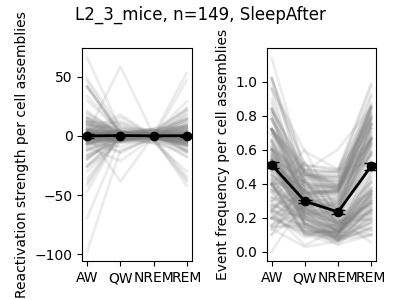

In [195]:
df_CellAss=df_CellAss_origin.copy()
df_CellAss = df_CellAss[df_CellAss['SubstateDuration'] != 0]

df_CellAss = df_CellAss[df_CellAss['ExpeType']=='SleepAfter']

# Convert string representations of lists into actual Python lists.
df_CellAss['Cells_in_Assembly']=df_CellAss['Cells_in_Assembly'] = df_CellAss['Cells_in_Assembly'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
# Filter the DataFrame to only keep rows where the number of cells in the list matches the 'Assembly_size'.
df_CellAss = df_CellAss[df_CellAss['Cells_in_Assembly'].apply(len) == df_CellAss['Assembly_size']]

plt.figure(figsize=(4, 3))
table_CellAss = df_CellAss.pivot_table(index='Assembly_ID', columns=[df_CellAss['Substate']], values='Avg_ReactStr', aggfunc='mean', fill_value=None)
desired_order = ['AW','QW', 'NREM', 'REM']   
try:del table_CellAss['undefined']
except: pass
try:del table_CellAss['IS']
except: pass
try: table_CellAss = table_CellAss[desired_order]
except: pass
plt.subplot(1,2,1)
plt.plot(table_CellAss.columns, table_CellAss.values.T, color= 'grey', alpha=0.15, linewidth=2)
plt.plot(table_CellAss.columns, table_CellAss.mean(), linewidth=2, color='black')
plt.errorbar(table_CellAss.columns, table_CellAss.mean(), yerr=table_CellAss.sem() ,
             fmt='o', color='black', capsize=5)
plt.ylabel('Reactivation strength per cell assemblies')
plt.tight_layout()

groups = [table_CellAss[col].dropna().values for col in table_CellAss.columns]
f_stat, p_value = f_oneway(*groups)
print(f"ANOVA result: F = {f_stat:.3f}, p = {p_value:.3e}")
df_melt = table_CellAss.melt(var_name='Substates', value_name='Avg_Activity')
df_melt = df_melt.dropna(subset=['Avg_Activity', 'Substates'])
df_melt['Avg_Activity'] = pd.to_numeric(df_melt['Avg_Activity'], errors='coerce')
tukey = pairwise_tukeyhsd(endog=df_melt['Avg_Activity'], groups=df_melt['Substates'], alpha=0.05)
print(tukey.summary())

table_CellAss = df_CellAss.pivot_table(index='Assembly_ID', columns=[df_CellAss['Substate']], values='EventFreq', aggfunc='mean', fill_value=None)
try:del table_CellAss['undefined']
except: pass
try:del table_CellAss['IS']
except: pass
try: table_CellAss = table_CellAss[desired_order]
except: pass
plt.subplot(1,2,2)
plt.plot(table_CellAss.columns, table_CellAss.values.T, color= 'grey', alpha=0.15, linewidth=2)
plt.plot(table_CellAss.columns, table_CellAss.mean(), linewidth=2, color='black')
plt.errorbar(table_CellAss.columns, table_CellAss.mean(), yerr=table_CellAss.sem() ,
            fmt='o', color='black', capsize=5)
plt.ylabel('Event frequency per cell assemblies')

groups = [table_CellAss[col].dropna().values for col in table_CellAss.columns]
f_stat, p_value = f_oneway(*groups)
print(f"ANOVA result: F = {f_stat:.3f}, p = {p_value:.3e}")
df_melt = table_CellAss.melt(var_name='Substates', value_name='EventFreq')
df_melt = df_melt.dropna(subset=['EventFreq', 'Substates'])
df_melt['EventFreq'] = pd.to_numeric(df_melt['EventFreq'], errors='coerce')
tukey = pairwise_tukeyhsd(endog=df_melt['EventFreq'], groups=df_melt['Substates'], alpha=0.05)
print(tukey.summary())
plt.suptitle(f'{NrSubtype}, n={len(table_CellAss)}, SleepAfter')
plt.tight_layout()
plt.savefig(f'{Path(path4).parent}/CellAssembly_VigStActivity.svg', format='svg', bbox_inches='tight', pad_inches=0, transparent=True)
plt.show()

## Cell assembly reactivation during vigilance states per ID

Identify Cell assembly Types and test proportion


Assembly Neuron ID Distribution Test
        ID   Obs    Mean     Std      Z  p-value
        PC    10    1.78    1.37   5.98   0.0002
     PC&HD     3    0.93    0.98   2.10   0.0706
BodyMotion    17   11.19    3.43   1.69   0.1112
unclassified    50   58.05    6.20  -1.30   0.1942
       mix    67   74.45    5.89  -1.27   0.2336
        HD     2    2.59    1.66  -0.36   0.7916


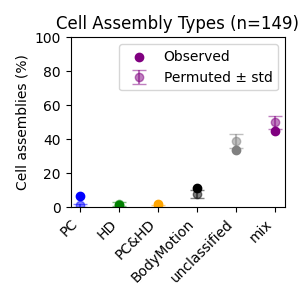

In [196]:
df_CellAss_uniqAss = df_CellAss.drop_duplicates(subset='Assembly_ID', keep='first')
df_CellAss_uniqAss = df_CellAss_uniqAss[df_CellAss_uniqAss['Cells_in_Assembly'].apply(len) == df_CellAss_uniqAss['Assembly_size']]
groups = df_CellAss_uniqAss['Cells_in_Assembly'].tolist()
ids=AllCheeseboard_cells.tolist()
cluster_labels = ['HD']*len(HD_cells) + ['PC']*len(PC_cells) + ['PC&HD']*len(PCHD_cells) + ['BodyMotion']*len(BodyMotion_cells)  + ['unclassified']*len(unclassified_cells) 

def classify_groups(groups, id_to_cluster):
    labels = []
    for group in groups:
        clusters = [id_to_cluster.get(i, np.nan) for i in group]
        if len(clusters) >= 1:
            count = Counter(clusters)
            top, n_top = count.most_common(1)[0]
            top_clusters = [k for k, v in count.items() if v == n_top]        
            # If there are multiple top clusters or the majority is less than 50%, label as "mix"
            if len(top_clusters) == 1 and (n_top / len(group) * 100) > 50 and not pd.isna(top):
                labels.append(top)
            else:
                labels.append("mix")  
        else:
            labels.append("mix")    
    return labels

# --- Observed classification
observed_labels = classify_groups(groups, id_to_cluster)
observed_counts = Counter(observed_labels)
df_CellAss_uniqAss['Assembly_Neurons_ID']= observed_labels

# --- Permutation test
n_perms = 5000
null_dists = defaultdict(list)

for _ in range(n_perms):
    # Shuffle cluster labels across individuals
    shuffled_clusters = dict(zip(ids, random.sample(cluster_labels, len(cluster_labels))))
    shuffled_labels = classify_groups(groups, shuffled_clusters)
    counts = Counter(shuffled_labels)
    for label in observed_counts:
        null_dists[label].append(counts.get(label, 0))

# --- Z-scores and p-values
results = []
for label in observed_counts:
    obs = observed_counts[label]
    null = null_dists[label]
    mean = np.mean(null)
    std = np.std(null)
    z = (obs - mean) / std if std > 0 else 0
    # Two-tailed p-value
    p = (np.sum(np.abs(np.array(null) - mean) >= abs(obs - mean)) + 1) / (n_perms + 1)
    results.append((label, obs, mean, std, z, p))

# --- Output
print("\nAssembly Neuron ID Distribution Test")
print(f"{'ID':>10} {'Obs':>5} {'Mean':>7} {'Std':>7} {'Z':>6} {'p-value':>8}")
for label, obs, mean, std, z, p in sorted(results, key=lambda x: x[-1]):
    print(f"{label:>10} {obs:5} {mean:7.2f} {std:7.2f} {z:6.2f} {p:8.4f}")


df_perm = pd.DataFrame(results, columns=["Cell_Assembly_ID", "Obs", "PermMean", "Std", "Z", "p"])
df_perm['Obs_prop'] = df_perm['Obs'] / df_perm['Obs'].sum() *100
df_perm['Perm_prop'] = df_perm['PermMean'] / df_perm['PermMean'].sum() *100
df_perm["Perm_std"] = df_perm["Std"] / df_perm["PermMean"].sum() *100

df_perm = df_perm.sort_values("Cell_Assembly_ID") 
df_perm['Cell_Assembly_ID'] = pd.Categorical(df_perm['Cell_Assembly_ID'], ["PC", "HD", "PC&HD", "BodyMotion", "unclassified", "mix"])
df_perm = df_perm.sort_values("Cell_Assembly_ID") 
df_perm['Cell_Assembly_ID'] = pd.Categorical(df_perm['Cell_Assembly_ID'], ["PC", "HD", "PC&HD", "BodyMotion", "unclassified", "mix"])
fig, ax= plt.subplots(figsize=(3, 3))
color_map = ['blue',  'green', 'orange','black', 'grey','purple']
for x, yperm, yobs, err, color in zip(df_perm["Cell_Assembly_ID"], df_perm["Perm_prop"], df_perm["Obs_prop"], df_perm["Perm_std"], color_map):
    line1 = ax.errorbar(x, yperm, yerr=err, fmt='o', color=color, capsize=5, alpha = 0.5, label = 'Permuted ± std')
    line2 = ax.scatter(x, yobs, color=color, label = 'Observed')
    ax.legend([line2, line1], ['Observed', 'Permuted ± std']) if x == 'mix' else None
plt.ylabel("Cell assemblies (%)")
plt.ylim(0, 100)
plt.title(f"Cell Assembly Types (n={len(df_CellAss_uniqAss)})")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{Path(path4).parent}/CellAssembly_Proportion_permvsreal_{drug}.svg', format='svg', bbox_inches='tight', pad_inches=0, transparent=True)
plt.show()


Assembly Neuron ID Distribution Test
        ID   Obs    Mean     Std      Z  p-value
   Spatial    27   14.88    3.91   3.10   0.0022
       mix    55   64.82    5.63  -1.75   0.0900
Non_Spatial    17   11.24    3.46   1.66   0.1076
   unknown    50   58.05    6.31  -1.28   0.2096


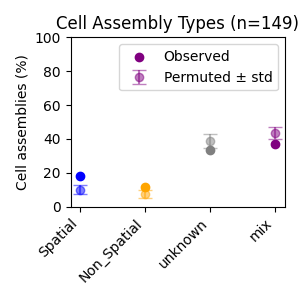

In [197]:
df_SpCellAss_uniqAss = df_CellAss.drop_duplicates(subset='Assembly_ID', keep='first')
df_SpCellAss_uniqAss = df_SpCellAss_uniqAss[df_SpCellAss_uniqAss['Cells_in_Assembly'].apply(len) == df_SpCellAss_uniqAss['Assembly_size']]
groups = df_SpCellAss_uniqAss['Cells_in_Assembly'].tolist()
ids=AllCheeseboard_cells.tolist()
cluster_labels = ['Spatial']*len(Spatial_cells) + ['Non_Spatial']*len(Non_Spatial_cells) + ['unknown']*len(unknown_cells) 

def classify_groups(groups, Spatial_id_to_cluster):
    labels = []
    for group in groups:
        clusters = [Spatial_id_to_cluster.get(i, np.nan) for i in group]
        if len(clusters) >= 1:
            count = Counter(clusters)
            top, n_top = count.most_common(1)[0]
            top_clusters = [k for k, v in count.items() if v == n_top]        
            # If there are multiple top clusters or the majority is less than 50%, label as "mix"
            if len(top_clusters) == 1 and (n_top / len(group) * 100) > 50 and not pd.isna(top):
                labels.append(top)
            else:
                labels.append("mix")  
        else:
            labels.append("mix")    
    return labels

# --- Observed classification
observed_labels = classify_groups(groups, Spatial_id_to_cluster)
observed_counts = Counter(observed_labels)
df_SpCellAss_uniqAss['Assembly_Spatial_ID']= observed_labels

# --- Permutation test
n_perms = 5000
null_dists = defaultdict(list)

for _ in range(n_perms):
    # Shuffle cluster labels across individuals
    shuffled_clusters = dict(zip(ids, random.sample(cluster_labels, len(cluster_labels))))
    shuffled_labels = classify_groups(groups, shuffled_clusters)
    counts = Counter(shuffled_labels)
    for label in observed_counts:
        null_dists[label].append(counts.get(label, 0))

# --- Z-scores and p-values
results = []
for label in observed_counts:
    obs = observed_counts[label]
    null = null_dists[label]
    mean = np.mean(null)
    std = np.std(null)
    z = (obs - mean) / std if std > 0 else 0
    # Two-tailed p-value
    p = (np.sum(np.abs(np.array(null) - mean) >= abs(obs - mean)) + 1) / (n_perms + 1)
    results.append((label, obs, mean, std, z, p))

# --- Output
print("\nAssembly Neuron ID Distribution Test")
print(f"{'ID':>10} {'Obs':>5} {'Mean':>7} {'Std':>7} {'Z':>6} {'p-value':>8}")
for label, obs, mean, std, z, p in sorted(results, key=lambda x: x[-1]):
    print(f"{label:>10} {obs:5} {mean:7.2f} {std:7.2f} {z:6.2f} {p:8.4f}")


df_perm = pd.DataFrame(results, columns=["Cell_Assembly_ID", "Obs", "PermMean", "Std", "Z", "p"])
df_perm['Obs_prop'] = df_perm['Obs'] / df_perm['Obs'].sum() *100
df_perm['Perm_prop'] = df_perm['PermMean'] / df_perm['PermMean'].sum() *100
df_perm["Perm_std"] = df_perm["Std"] / df_perm["PermMean"].sum() *100
df_perm = df_perm.sort_values("Cell_Assembly_ID") 
df_perm['Cell_Assembly_ID'] = pd.Categorical(df_perm['Cell_Assembly_ID'], ["Spatial", "Non_Spatial", "unknown", "mix"])
df_perm = df_perm.sort_values("Cell_Assembly_ID") 
df_perm['Cell_Assembly_ID'] = pd.Categorical(df_perm['Cell_Assembly_ID'], ["Spatial", "Non_Spatial", "unknown","mix"])

fig, ax= plt.subplots(figsize=(3, 3))
color_map = ['blue', 'orange', 'grey', 'purple']
for x, yperm, yobs, err, color in zip(df_perm["Cell_Assembly_ID"], df_perm["Perm_prop"], df_perm["Obs_prop"], df_perm["Perm_std"], color_map):
    line1= ax.errorbar(x, yperm, yerr=err, fmt='o', color=color, capsize=5, alpha = 0.5, label = 'Permuted ± std')
    line2= ax.scatter(x, yobs, color=color, label = 'Observed')
    ax.legend([line2, line1], ['Observed', 'Permuted ± std']) if x == 'mix' else None
plt.ylabel("Cell assemblies (%)")
plt.ylim(0, 100)
plt.title(f"Cell Assembly Types (n={len(df_SpCellAss_uniqAss)})")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{Path(path4).parent}/SpatialCellAssembly_Proportion_permvsreal_{drug}.svg', format='svg', bbox_inches='tight', pad_inches=0, transparent=True)
plt.show()

Identify modulated cell assemblies during Post Session

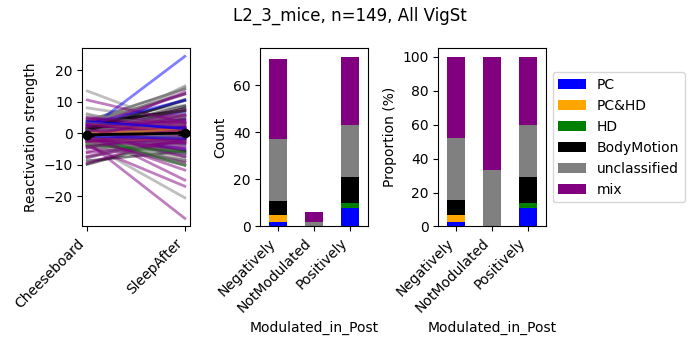

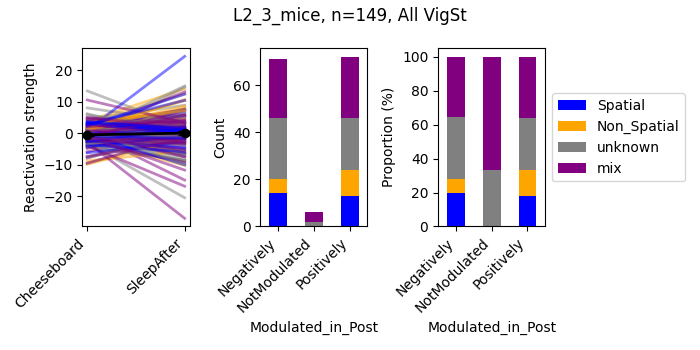

In [198]:
df_CellAss = df_CellAss_origin.copy()
df_CellAss = df_CellAss[df_CellAss['SubstateDuration'] != 0]

initial_nb= df_CellAss['Assembly_ID'].nunique()
df_CellAss = df_CellAss[df_CellAss['Assembly_size'] > 1]
df_CellAss['Cells_in_Assembly']=df_CellAss['Cells_in_Assembly'] = df_CellAss['Cells_in_Assembly'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
df_CellAss = df_CellAss[df_CellAss['Cells_in_Assembly'].apply(len) == df_CellAss['Assembly_size']]


table_CellAss = df_CellAss.pivot_table(index='Assembly_ID', columns=[df_CellAss['ExpeType']], values='Avg_ReactStr', aggfunc='mean', fill_value=None)
table_CellAss['Diff']=(table_CellAss['Cheeseboard']-table_CellAss['SleepAfter'])/table_CellAss['Cheeseboard']*100
table_CellAss['Modulated_in_Post']=np.where(table_CellAss['Diff'] > 20, 'Negatively', np.where(table_CellAss['Diff'] < -20, 'Positively', 'NotModulated'))

plt.close('all')

df_CellAss_uniqAss_Mod = pd.merge(df_CellAss_uniqAss, table_CellAss[['Modulated_in_Post']], on='Assembly_ID', how='outer')

fig, axes = plt.subplots(1, 3, figsize=(7, 3.5))
table_ = df_CellAss.pivot_table(index='Assembly_ID', columns=[df_CellAss['ExpeType']], values='Avg_ReactStr', aggfunc='mean', fill_value=None)
table_ = pd.merge(table_,df_CellAss_uniqAss_Mod[['Assembly_ID', 'Assembly_Neurons_ID']], on='Assembly_ID', how='outer')

desired_order = ['Cheeseboard','SleepAfter', 'Assembly_Neurons_ID']   
try: table_ = table_[desired_order]
except: pass
color_map = {'PC': 'blue', 'PC&HD': 'orange', 'HD': 'green', 'BodyMotion': 'black', 'unclassified': 'grey','mix': 'purple'}
table_ = table_[~table_['Assembly_Neurons_ID'].isna()]
for idx, row in table_.iterrows():
    axes[0].plot(table_.columns[:-1], [row['Cheeseboard'], row['SleepAfter']], color=color_map[row['Assembly_Neurons_ID']], alpha=0.5, linewidth=2)
axes[0].plot(table_.columns[:-1], table_.iloc[:, :-1].mean(), linewidth=2, color='black')
axes[0].errorbar(table_.columns[:-1], table_.iloc[:, :-1].mean(), yerr=table_.iloc[:, :-1].sem(), fmt='o', color='black', capsize=5)
axes[0].set_ylabel('Reactivation strength')
axes[0].set_xticklabels(table_.columns[:-1], rotation=45, ha='right')

color_m = ['blue', 'orange', 'green', 'black', 'grey', 'purple']
grouped_proportions = df_CellAss_uniqAss_Mod.groupby('Modulated_in_Post')['Assembly_Neurons_ID'].value_counts(normalize=False).unstack()
desired_order = ['PC', 'PC&HD', 'HD', 'BodyMotion', 'unclassified', 'mix']   
try: grouped_proportions = grouped_proportions[desired_order]
except: pass
grouped_proportions.plot(kind='bar', stacked=True, ax=axes[1], color=color_m)
axes[1].set_ylabel('Count')
axes[1].get_legend().remove()  
axes[1].set_xticklabels(grouped_proportions.index, rotation=45, ha='right')

grouped_proportions = df_CellAss_uniqAss_Mod.groupby('Modulated_in_Post')['Assembly_Neurons_ID'].value_counts(normalize=True).unstack()*100
try: grouped_proportions = grouped_proportions[desired_order]
except: pass
grouped_proportions.plot(kind='bar', stacked=True, ax=axes[2], color=color_m)
axes[2].set_ylabel('Proportion (%)')
axes[2].legend(loc='center left', bbox_to_anchor=(1, 0.5))
axes[2].set_xticklabels(grouped_proportions.index, rotation=45, ha='right')

fig.suptitle(f'{NrSubtype}, n={len(table_)}, All VigSt')
plt.tight_layout()
plt.savefig(f'{Path(path4).parent}/CellAssembly_Modulated_PostAllVigSt.svg', format='svg', bbox_inches='tight', pad_inches=0, transparent=True)
plt.show()



df_SpCellAss_uniqAss_Mod = pd.merge(df_SpCellAss_uniqAss,table_CellAss[['Modulated_in_Post']], on='Assembly_ID', how='outer')

fig, axes = plt.subplots(1, 3, figsize=(7, 3.5))
table_ = df_CellAss.pivot_table(index='Assembly_ID', columns=[df_CellAss['ExpeType']], values='Avg_ReactStr', aggfunc='mean', fill_value=None)
table_ = pd.merge(table_,df_SpCellAss_uniqAss_Mod[['Assembly_ID', 'Assembly_Spatial_ID']], on='Assembly_ID', how='outer')

desired_order = ['Cheeseboard','SleepAfter', 'Assembly_Spatial_ID']   
try: table_ = table_[desired_order]
except: pass
color_map = {'Spatial': 'blue', 'Non_Spatial': 'orange', 'unknown': 'grey', 'mix': 'purple'}
table_ = table_[~table_['Assembly_Spatial_ID'].isna()]
for idx, row in table_.iterrows():
    axes[0].plot(table_.columns[:-1], [row['Cheeseboard'], row['SleepAfter']], color=color_map[row['Assembly_Spatial_ID']], alpha=0.5, linewidth=2)
axes[0].plot(table_.columns[:-1], table_.iloc[:, :-1].mean(), linewidth=2, color='black')
axes[0].errorbar(table_.columns[:-1], table_.iloc[:, :-1].mean(), yerr=table_.iloc[:, :-1].sem(), fmt='o', color='black', capsize=5)
axes[0].set_ylabel('Reactivation strength')
axes[0].set_xticklabels(table_.columns[:-1], rotation=45, ha='right')

grouped_proportions = df_SpCellAss_uniqAss_Mod.groupby('Modulated_in_Post')['Assembly_Spatial_ID'].value_counts(normalize=False).unstack()
color_m = ['blue', 'orange', 'grey', 'purple']
desired_order = ['Spatial', 'Non_Spatial', 'unknown',  'mix']   
try: grouped_proportions = grouped_proportions[desired_order]
except: pass
grouped_proportions.plot(kind='bar', stacked=True, ax=axes[1], color=color_m)
axes[1].set_ylabel('Count')
axes[1].get_legend().remove()  
axes[1].set_xticklabels(grouped_proportions.index, rotation=45, ha='right')

grouped_proportions = df_SpCellAss_uniqAss_Mod.groupby('Modulated_in_Post')['Assembly_Spatial_ID'].value_counts(normalize=True).unstack()*100
try: grouped_proportions = grouped_proportions[desired_order]
except: pass
grouped_proportions.plot(kind='bar', stacked=True, ax=axes[2],color=color_m)
axes[2].set_ylabel('Proportion (%)')
axes[2].legend(loc='center left', bbox_to_anchor=(1, 0.5))
axes[2].set_xticklabels(grouped_proportions.index, rotation=45, ha='right')

fig.suptitle(f'{NrSubtype}, n={len(table_)}, All VigSt')
plt.tight_layout()
plt.savefig(f'{Path(path4).parent}/CellAssemblySpatial_Modulated_PostAllVigSt.svg', format='svg', bbox_inches='tight', pad_inches=0, transparent=True)
plt.show()


Identify modulated cell assemblies during AW Post Session

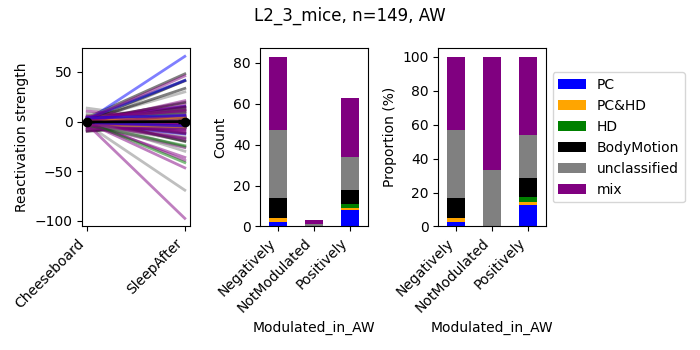

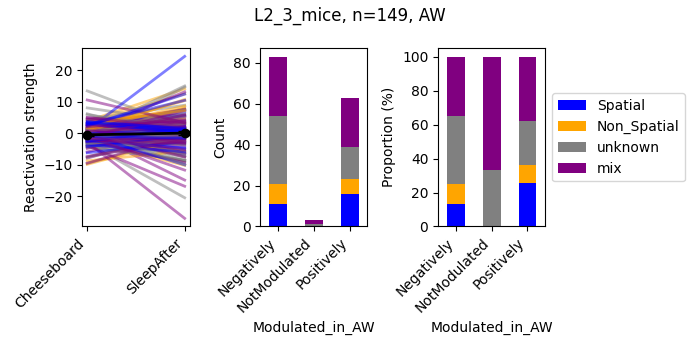

In [199]:
df_CellAssAW = df_CellAss_origin.copy()
df_CellAssAW = df_CellAssAW[df_CellAssAW['SubstateDuration'] != 0]

df_CellAssAW = df_CellAssAW[df_CellAssAW['Substate']=='AW']

initial_nb= df_CellAssAW['Assembly_ID'].nunique()
df_CellAssAW = df_CellAssAW[df_CellAssAW['Assembly_size'] > 1]
df_CellAssAW['Cells_in_Assembly']=df_CellAssAW['Cells_in_Assembly'] = df_CellAssAW['Cells_in_Assembly'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
df_CellAssAW = df_CellAssAW[df_CellAssAW['Cells_in_Assembly'].apply(len) == df_CellAssAW['Assembly_size']]


table_CellAss = df_CellAssAW.pivot_table(index='Assembly_ID', columns=[df_CellAssAW['ExpeType']], values='Avg_ReactStr', aggfunc='mean', fill_value=None)
table_CellAss['Diff']=(table_CellAss['Cheeseboard']-table_CellAss['SleepAfter'])/table_CellAss['Cheeseboard']*100
table_CellAss['Modulated_in_AW']=np.where(table_CellAss['Diff'] > 20, 'Negatively', np.where(table_CellAss['Diff'] < -20, 'Positively', 'NotModulated'))

plt.close('all')

df_CellAss_uniqAss_Mod2 = pd.merge(df_CellAss_uniqAss, table_CellAss[['Modulated_in_AW']], on='Assembly_ID', how='outer')

fig, axes = plt.subplots(1, 3, figsize=(7, 3.5))
table_ = df_CellAssAW.pivot_table(index='Assembly_ID', columns=[df_CellAssAW['ExpeType']], values='Avg_ReactStr', aggfunc='mean', fill_value=None)
table_ = pd.merge(table_,df_CellAss_uniqAss_Mod2[['Assembly_ID', 'Assembly_Neurons_ID']], on='Assembly_ID', how='outer')

desired_order = ['Cheeseboard','SleepAfter', 'Assembly_Neurons_ID']   
try: table_ = table_[desired_order]
except: pass
color_map = {'PC': 'blue', 'PC&HD': 'orange', 'HD': 'green', 'BodyMotion': 'black', 'unclassified': 'grey', 'mix': 'purple'}
table_ = table_[~table_['Assembly_Neurons_ID'].isna()]
for idx, row in table_.iterrows():
    axes[0].plot(table_.columns[:-1], [row['Cheeseboard'], row['SleepAfter']], color=color_map[row['Assembly_Neurons_ID']], alpha=0.5, linewidth=2)
axes[0].plot(table_.columns[:-1], table_.iloc[:, :-1].mean(), linewidth=2, color='black')
axes[0].errorbar(table_.columns[:-1], table_.iloc[:, :-1].mean(), yerr=table_.iloc[:, :-1].sem(), fmt='o', color='black', capsize=5)
axes[0].set_ylabel('Reactivation strength')
axes[0].set_xticklabels(table_.columns[:-1], rotation=45, ha='right')

color_m = ['blue', 'orange', 'green', 'black', 'grey', 'purple']
grouped_proportions = df_CellAss_uniqAss_Mod2.groupby('Modulated_in_AW')['Assembly_Neurons_ID'].value_counts(normalize=False).unstack()
desired_order = ['PC', 'PC&HD', 'HD', 'BodyMotion', 'unclassified', 'mix']   
try: grouped_proportions = grouped_proportions[desired_order]
except: pass
grouped_proportions.plot(kind='bar', stacked=True, ax=axes[1], color=color_m)
axes[1].set_ylabel('Count')
axes[1].get_legend().remove()  
axes[1].set_xticklabels(grouped_proportions.index, rotation=45, ha='right')

grouped_proportions = df_CellAss_uniqAss_Mod2.groupby('Modulated_in_AW')['Assembly_Neurons_ID'].value_counts(normalize=True).unstack()*100
desired_order = ['PC', 'PC&HD', 'HD', 'BodyMotion', 'unclassified', 'mix']   
try: grouped_proportions = grouped_proportions[desired_order]
except: pass
grouped_proportions.plot(kind='bar', stacked=True, ax=axes[2], color=color_m)
axes[2].set_ylabel('Proportion (%)')
axes[2].legend(loc='center left', bbox_to_anchor=(1, 0.5))
axes[2].set_xticklabels(grouped_proportions.index, rotation=45, ha='right')

fig.suptitle(f'{NrSubtype}, n={len(table_)}, AW')
plt.tight_layout()
plt.savefig(f'{Path(path4).parent}/CellAssembly_Modulated_Post_AW.svg', format='svg', bbox_inches='tight', pad_inches=0, transparent=True)
plt.show()



df_SpCellAss_uniqAss_Mod2 = pd.merge(df_SpCellAss_uniqAss,table_CellAss[['Modulated_in_AW']], on='Assembly_ID', how='outer')

fig, axes = plt.subplots(1, 3, figsize=(7, 3.5))
table_ = df_CellAss.pivot_table(index='Assembly_ID', columns=[df_CellAss['ExpeType']], values='Avg_ReactStr', aggfunc='mean', fill_value=None)
table_ = pd.merge(table_,df_SpCellAss_uniqAss_Mod2[['Assembly_ID', 'Assembly_Spatial_ID']], on='Assembly_ID', how='outer')

desired_order = ['Cheeseboard','SleepAfter', 'Assembly_Spatial_ID']   
try: table_ = table_[desired_order]
except: pass
color_map = {'Spatial': 'blue', 'Non_Spatial': 'orange', 'unknown': 'grey', 'mix': 'purple'}
table_ = table_[~table_['Assembly_Spatial_ID'].isna()]
for idx, row in table_.iterrows():
    axes[0].plot(table_.columns[:-1], [row['Cheeseboard'], row['SleepAfter']], color=color_map[row['Assembly_Spatial_ID']], alpha=0.5, linewidth=2)
axes[0].plot(table_.columns[:-1], table_.iloc[:, :-1].mean(), linewidth=2, color='black')
axes[0].errorbar(table_.columns[:-1], table_.iloc[:, :-1].mean(), yerr=table_.iloc[:, :-1].sem(), fmt='o', color='black', capsize=5)
axes[0].set_ylabel('Reactivation strength')
axes[0].set_xticklabels(table_.columns[:-1], rotation=45, ha='right')

grouped_proportions = df_SpCellAss_uniqAss_Mod2.groupby('Modulated_in_AW')['Assembly_Spatial_ID'].value_counts(normalize=False).unstack()
color_m = ['blue', 'orange', 'grey', 'purple']
desired_order = ['Spatial', 'Non_Spatial', 'unknown', 'mix']   
try: grouped_proportions = grouped_proportions[desired_order]
except: pass
grouped_proportions.plot(kind='bar', stacked=True, ax=axes[1], color=color_m)
axes[1].set_ylabel('Count')
axes[1].get_legend().remove()  
axes[1].set_xticklabels(grouped_proportions.index, rotation=45, ha='right')

grouped_proportions = df_SpCellAss_uniqAss_Mod2.groupby('Modulated_in_AW')['Assembly_Spatial_ID'].value_counts(normalize=True).unstack()*100
try: grouped_proportions = grouped_proportions[desired_order]
except: pass
grouped_proportions.plot(kind='bar', stacked=True, ax=axes[2],color=color_m)
axes[2].set_ylabel('Proportion (%)')
axes[2].legend(loc='center left', bbox_to_anchor=(1, 0.5))
axes[2].set_xticklabels(grouped_proportions.index, rotation=45, ha='right')

fig.suptitle(f'{NrSubtype}, n={len(table_)}, AW')
plt.tight_layout()
plt.savefig(f'{Path(path4).parent}/CellAssemblySpatial_Modulated_Post_AW.svg', format='svg', bbox_inches='tight', pad_inches=0, transparent=True)
plt.show()


Add & save Assembly main identity

In [200]:
df_CellAss_ID_ = pd.merge(df_CellAss,df_CellAss_uniqAss_Mod[['Assembly_ID', 'Assembly_Neurons_ID','Modulated_in_Post']], on='Assembly_ID', how='outer')
df_CellAss_ID = pd.merge(df_CellAss_ID_,df_SpCellAss_uniqAss_Mod2[['Assembly_ID', 'Assembly_Spatial_ID', 'Modulated_in_AW']], on='Assembly_ID', how='outer')

filenameOut = Path(path4).parent / f'CellAssembly_Global_ID.pkl'
with open(filenameOut, 'wb') as pickle_file:
    pickle.dump(df_CellAss_ID, pickle_file)    
filenameOut = Path(path4).parent / f'CellAssembly_Global_ID.xlsx'
with pd.ExcelWriter(filenameOut) as writer:
    df_CellAss_ID.to_excel(writer, index=False)

### HD vs PC vs HDPC vs notHDnotPC

Plot Reactivation of cell assemblies

############################ SleepAfter ############################
ANOVA result: F = 1.988, p = 8.388e-02
############################ AW ############################
ANOVA result: F = 2.604, p = 2.755e-02
      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
  group1      group2    meandiff p-adj   lower    upper  reject
---------------------------------------------------------------
BodyMotion           HD -16.6434 0.0554  -33.512  0.2252  False
BodyMotion           PC   1.5669  0.996   -7.426 10.5598  False
BodyMotion        PC&HD  -2.4984 0.9957 -16.6294 11.6325  False
BodyMotion          mix  -3.6903 0.5081  -9.8183  2.4377  False
BodyMotion unclassified  -3.7628 0.5237 -10.0981  2.5725  False
        HD           PC  18.2103 0.0358   0.7313 35.6893   True
        HD        PC&HD   14.145 0.3568  -6.4542 34.7442  False
        HD          mix  12.9531 0.1965  -3.2394 29.1455  False
        HD unclassified  12.8806 0.2063  -3.3915 29.1527  False
        PC        PC&HD 

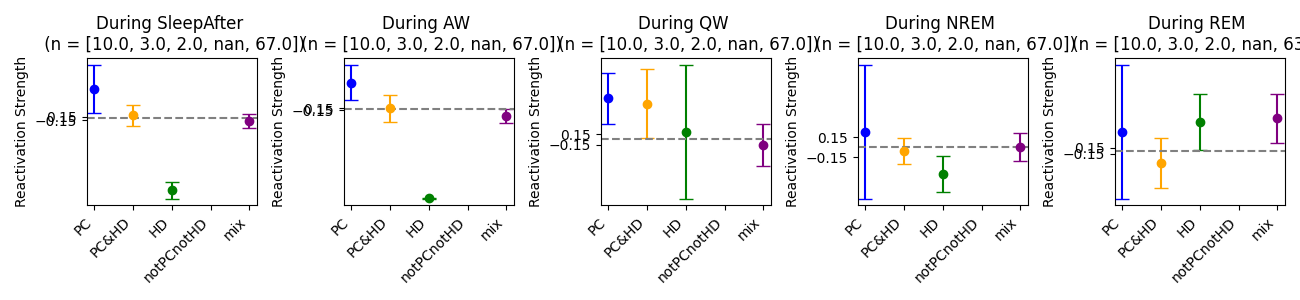

In [201]:
fig, axs = plt.subplots(1, 5, figsize=(13,3))
axs = axs.flatten()
substates= ['SleepAfter', 'AW', 'QW', 'NREM', 'REM']
#df_CellAss = df_CellAss[df_CellAss['ExpeType']=='SleepAfter']

for plot, substate in enumerate(substates): 
    ax= axs[plot]

    df_CellAss_ID_ = df_CellAss_ID[(df_CellAss_ID['Substate'] == substate)] if not substate =='SleepAfter' else df_CellAss_ID
    CellAss_ID_pivot= df_CellAss_ID_.pivot_table(index='Assembly_ID', columns=['Assembly_Neurons_ID'], values='Avg_ReactStr', aggfunc='mean', fill_value=None)

    g = pd.DataFrame({"mean": np.nanmean(CellAss_ID_pivot, axis=0),"sem": CellAss_ID_pivot.sem(skipna=True),"count" : CellAss_ID_pivot.count()})
    g = g.reindex(['PC', 'PC&HD', 'HD', 'notPCnotHD', 'mix'])   
    color_map = {'PC': 'blue', 'PC&HD': 'orange', 'HD': 'green', 'notPCnotHD': 'black','mix': 'purple'} 
    colors = [color_map[c] for c in g.index]   # in order of shown categories
    for x,(m,e,c) in enumerate(zip(g['mean'], g['sem'], colors)):
        ax.errorbar(x, m, yerr=e, fmt='o', capsize=5, color=c)
    ax.set_ylabel('Reactivation Strength')
    ax.axhline(y=0, linestyle='--', color='grey')
    ax.set_xticks(range(len(g)), g.index, rotation=45, ha='right')
    ax.set_yticks((-.15,.15))
    ax.set_title(f"During {substate} \n (n = {g['count'].values.tolist()})")
    
    print(f'############################ {substate} ############################')    
    groups = [CellAss_ID_pivot[col].dropna().values for col in CellAss_ID_pivot.columns]
    f_stat, p_value = f_oneway(*groups)
    print(f"ANOVA result: F = {f_stat:.3f}, p = {p_value:.3e}")
    if p_value<0.05:
        df_melt = CellAss_ID_pivot.melt(var_name='Assembly_Neurons_ID', value_name='Avg_ReactStr')
        df_melt = df_melt.dropna(subset=['Avg_ReactStr', 'Assembly_Neurons_ID'])
        df_melt['Avg_ReactStr'] = pd.to_numeric(df_melt['Avg_ReactStr'], errors='coerce')
        tukey = pairwise_tukeyhsd(endog=df_melt['Avg_ReactStr'], groups=df_melt['Assembly_Neurons_ID'], alpha=0.05)
        print(tukey.summary())

plt.tight_layout()
plt.savefig(f'{Path(path4).parent}/CellAssemblyRS_perVigSt&NeuronID.svg', format='svg', bbox_inches='tight', pad_inches=0, transparent=True)
plt.show()

Cell assembly size

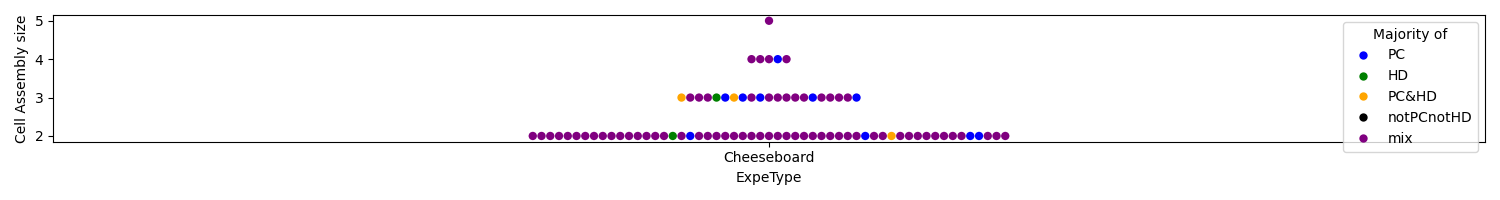

In [202]:
CellAss_ID_pivot= df_CellAss_ID.pivot_table(index='Assembly_ID', columns=['ExpeType'], values='Assembly_size', aggfunc='mean', fill_value=None)
CellAss_ID_pivot_clean = pd.merge(CellAss_ID_pivot,df_CellAss_ID[['Assembly_Neurons_ID', 'Assembly_ID']], on='Assembly_ID', how='inner')
CellAss_ID_pivot_clean = CellAss_ID_pivot_clean.drop_duplicates()

color_map = {'PC': 'blue', 'PC&HD': 'orange', 'HD': 'green', 
             'notPCnotHD': 'black', 'mix': 'purple'}

df_melted = CellAss_ID_pivot_clean.melt(
    id_vars='Assembly_Neurons_ID',
    value_vars=['SleepAfter'],
    var_name='ExpeType',
    value_name='Assembly_size'
)
df_melted['Assembly_Neurons_ID'] = pd.Categorical(df_melted['Assembly_Neurons_ID'], ["PC", "HD", "PC&HD", "notPCnotHD", "mix"])

fig, ax= plt.subplots(figsize=(15,2))
sns.swarmplot(
    x='ExpeType', 
    y='Assembly_size', 
    data=df_melted, 
    hue='Assembly_Neurons_ID', 
    palette=color_map, 
    size=6, 
    alpha=1,
    ax= ax,
)
plt.ylabel('Cell Assembly size')
plt.xticks([0], ['Cheeseboard'])
plt.legend(loc='upper right', title='Majority of')
plt.tight_layout()
plt.savefig(f'{Path(path4).parent}/CellAssemblySize_perExpeType.svg', format='svg', bbox_inches='tight', pad_inches=0, transparent=True)
plt.show()


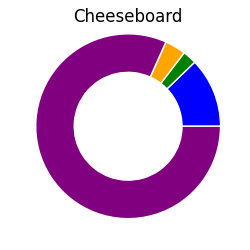

In [203]:
fig, ax = plt.subplots(figsize=(2.5,2.5))
df_melted_ = df_melted.dropna().groupby(['ExpeType','Assembly_Neurons_ID']).size().reset_index(name='count')
pivot_df = df_melted_.pivot(index='ExpeType', columns='Assembly_Neurons_ID', values='count').fillna(0)
size = 0.5
vals_outer = df_melted_[df_melted_['ExpeType']=='SleepAfter']['count'].tolist()
color_map = ['blue', 'green', 'orange', 'black', 'purple']

ax.pie(vals_outer, radius=1.2, colors=color_map, #labels=['Spatial', 'Non_Spatial', 'unclassified', 'mix'],
       wedgeprops=dict(width=size, edgecolor='w'))
ax.set(aspect="equal", title= 'Cheeseboard')
plt.savefig(f'{Path(path4).parent}/CellAssemblyProportion_NestedPieChart_perExpeType.svg', format='svg', bbox_inches='tight', pad_inches=0, transparent=True)
plt.show()

### Spatially-tuned vs non Spatially-tuned

Plot Reactivation of cell assemblies

############################ SleepAfter ############################
ANOVA result: F = 1.770, p = 1.556e-01
############################ AW ############################
ANOVA result: F = 1.451, p = 2.306e-01
############################ QW ############################
ANOVA result: F = 0.312, p = 8.164e-01
############################ NREM ############################
ANOVA result: F = 0.254, p = 8.583e-01
############################ REM ############################
ANOVA result: F = 2.345, p = 7.547e-02


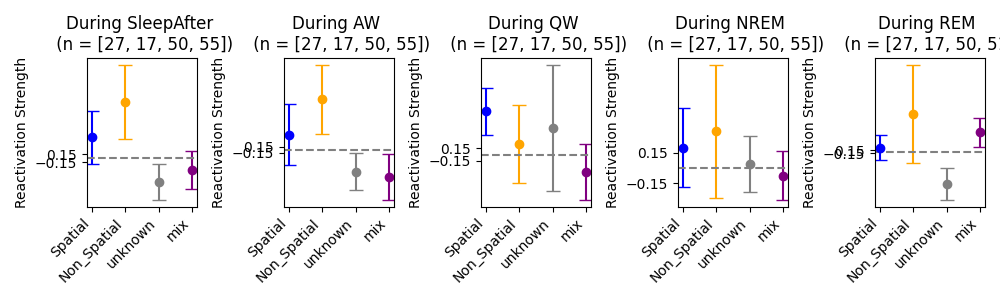

In [204]:
fig, axs = plt.subplots(1, 5, figsize=(10,3))
axs = axs.flatten()
substates= ['SleepAfter', 'AW', 'QW', 'NREM', 'REM']
for plot, substate in enumerate(substates): 
    ax= axs[plot]

    df_CellAss_ID_ = df_CellAss_ID[(df_CellAss_ID['Substate'] == substate)] if not substate =='SleepAfter' else df_CellAss_ID
    CellAss_ID_pivot= df_CellAss_ID_.pivot_table(index='Assembly_ID', columns=['Assembly_Spatial_ID'], values='Avg_ReactStr', aggfunc='mean', fill_value=None)

    g = pd.DataFrame({"mean": np.nanmean(CellAss_ID_pivot, axis=0),"sem": CellAss_ID_pivot.sem(skipna=True),"count" : CellAss_ID_pivot.count()})
    g = g.reindex(['Spatial', 'Non_Spatial', 'unknown',  'mix'])   
    color_map = {'Spatial': 'blue', 'Non_Spatial': 'orange', 'unknown': 'grey', 'mix': 'purple'} 
    colors = [color_map[c] for c in g.index]   # in order of shown categories
    for x,(m,e,c) in enumerate(zip(g['mean'], g['sem'], colors)):
        ax.errorbar(x, m, yerr=e, fmt='o', capsize=5, color=c)
    ax.set_ylabel('Reactivation Strength')
    ax.axhline(y=0, linestyle='--', color='grey')
    ax.set_xticks(range(len(g)), g.index, rotation=45, ha='right')
    ax.set_yticks((-.15,.15))
    ax.set_title(f"During {substate} \n (n = {g['count'].values.tolist()})")
    
    print(f'############################ {substate} ############################')    
    groups = [CellAss_ID_pivot[col].dropna().values for col in CellAss_ID_pivot.columns]
    f_stat, p_value = f_oneway(*groups)
    print(f"ANOVA result: F = {f_stat:.3f}, p = {p_value:.3e}")
    if p_value<0.05: 
        df_melt = CellAss_ID_pivot.melt(var_name='Assembly_Spatial_ID', value_name='Avg_ReactStr')
        df_melt = df_melt.dropna(subset=['Avg_ReactStr', 'Assembly_Spatial_ID'])
        df_melt['Avg_ReactStr'] = pd.to_numeric(df_melt['Avg_ReactStr'], errors='coerce')
        tukey = pairwise_tukeyhsd(endog=df_melt['Avg_ReactStr'], groups=df_melt['Assembly_Spatial_ID'], alpha=0.05)
        print(tukey.summary())

plt.tight_layout()
plt.savefig(f'{Path(path4).parent}/CellAssemblyRS_perVigSt&SpatialID.svg', format='svg', bbox_inches='tight', pad_inches=0, transparent=True)
plt.show()

Cell assembly size

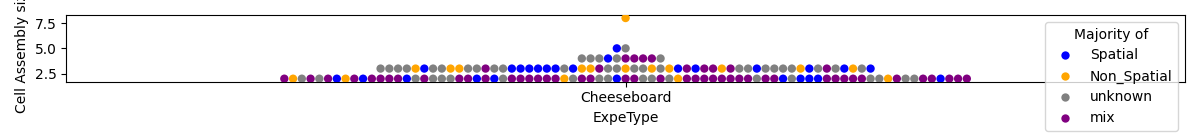

In [205]:
CellAss_ID_pivot = df_CellAss_ID.pivot_table(index='Assembly_ID', columns=['ExpeType'], values='Assembly_size', aggfunc='mean', fill_value=None)
CellAss_ID_pivot_clean = pd.merge(CellAss_ID_pivot,df_CellAss_ID[['Assembly_Spatial_ID', 'Assembly_ID']], on='Assembly_ID', how='inner')
CellAss_ID_pivot_clean = CellAss_ID_pivot_clean.drop_duplicates()

color_map = {'Spatial': 'blue', 'Non_Spatial': 'orange', 'unknown': 'grey', 'mix': 'purple'} 

df_melted = CellAss_ID_pivot_clean.melt(
    id_vars='Assembly_Spatial_ID',
    value_vars=['SleepAfter'],
    var_name='ExpeType',
    value_name='Assembly_size'
)
df_melted['Assembly_Spatial_ID'] = pd.Categorical(df_melted['Assembly_Spatial_ID'], ["Spatial", "Non_Spatial", 'unknown', "mix"])

fig, ax= plt.subplots(figsize=(12,1.4))
sns.swarmplot(
    x='ExpeType', 
    y='Assembly_size', 
    data=df_melted, 
    hue='Assembly_Spatial_ID', 
    palette=color_map, 
    size=6, 
    alpha=1,
    ax= ax,
)
plt.ylabel('Cell Assembly size')
plt.xticks([0], ['Cheeseboard'])
plt.legend(loc='upper right', title='Majority of')
plt.tight_layout()
plt.savefig(f'{Path(path4).parent}/CellAssemblySize_Spatial_perExpeType.svg', format='svg', bbox_inches='tight', pad_inches=0, transparent=True)
plt.show()

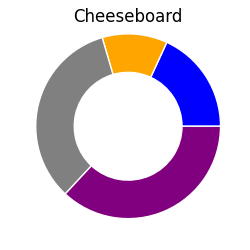

In [206]:
fig, ax = plt.subplots(figsize=(2.5,2.5))
df_melted_ = df_melted.dropna().groupby(['ExpeType','Assembly_Spatial_ID']).size().reset_index(name='count')
pivot_df = df_melted_.pivot(index='ExpeType', columns='Assembly_Spatial_ID', values='count').fillna(0)
size = .5
vals_outer = df_melted_[df_melted_['ExpeType']=='SleepAfter']['count'].tolist()
color_map = ['blue', 'orange', 'grey', 'purple',]

ax.pie(vals_outer, radius=1.2, colors=color_map, #labels=['Spatial', 'Non_Spatial', 'unclassified', 'mix'],
       wedgeprops=dict(width=size, edgecolor='w'))
ax.set(aspect="equal", title= 'Cheeseboard')
plt.savefig(f'{Path(path4).parent}/CellAssemblyProportion_Spatial_NestedPieChart_perExpeType.svg', format='svg', bbox_inches='tight', pad_inches=0, transparent=True)
plt.show()

## Cell assembly reactivation around oscillations per ID

In [ ]:
path5=f"/crnldata/forgetting/Aurelie/MiniscopeOE_analysis/Exploration_task/{analysisfolder5}/" #//10.69.168.1
path4b=f"/crnldata/forgetting/Aurelie/MiniscopeOE_analysis/Exploration_task/{analysisfolder4}/CellAssembly_Global_ID.pkl" #//10.69.168.1
with open(path4b, 'rb') as pickle_file:
    df_CellAss_ID = pickle.load(pickle_file)

Save Global in .csv for R

In [207]:
with open(f"{path5}/SWR_Global.pkl", "rb") as f:
    SWR = pickle.load(f)
SWR['SWR_ID'] = SWR['Mice'] +'_'+ SWR['Session'] + '_'+ SWR['SWRNumber'].astype(str)
SWR['SWRlenght'] = SWR['SWRDuration'].apply(lambda x: 'Long' if x >= 47 else 'Short')
SWR = pd.merge(SWR, df_CellAss_ID[['Assembly_ID', 'Assembly_Spatial_ID', 'Assembly_Neurons_ID', 'Modulated_in_Post', 'Modulated_in_AW']].drop_duplicates(), on='Assembly_ID', how='outer')
SWR['Assembly_size'] = SWR['Cells_in_Assembly'].apply(count_items)
SWR = SWR[SWR['Assembly_size'] >= min_cell_ass_size]

# remove if none of the sign cells are in the reactivation 

mask = SWR["Cells_in_Assembly_in_rec"].apply(lambda x: not any(ast.literal_eval(x)))
SWR=SWR[~mask]
"""
# remove if not all sign cells are in the reactivation 
mask = SWR["Cells_in_Assembly_in_rec"].apply(lambda x: all(ast.literal_eval(x)))
SWR=SWR[mask]
"""

# Keep only cell assemblies from the same session date as their recording session
df_CellAss_ID['Assembly_ID_sess'] = df_CellAss_ID['Assembly_ID'].str.rsplit('_', n=1).str[0]
Corr_df=df_CellAss_ID.explode("Assembly_ID_sess")[['Session_Date', 'Session']].drop_duplicates()
SWR['Assembly_ID_sess'] = SWR['Assembly_ID'].str.rsplit('_', n=1).str[0]
SWR['Cell_assembly_Date'] = SWR['Assembly_ID_sess'].map(Corr_df.set_index('Session')['Session_Date'])
SWR = SWR[SWR['Cell_assembly_Date'] == SWR['Session_Date']]
SWR.to_csv(f"{path5}/SWR_Global_ID.csv", index=False)



with open(f"{path5}/Spdl_Global.pkl", "rb") as f:
    SPDL = pickle.load(f)
SPDL['Spdl_ID'] = SPDL['Mice'] +'_'+ SPDL['Session'] + '_'+ SPDL['SpdlNumber'].astype(str)
SPDL = pd.merge(SPDL, df_CellAss_ID[['Assembly_ID', 'Assembly_Spatial_ID', 'Assembly_Neurons_ID']].drop_duplicates(), on='Assembly_ID', how='outer')
SPDL['Assembly_size'] = SPDL['Cells_in_Assembly'].apply(count_items)
SPDL = SPDL[SPDL['Assembly_size'] >= min_cell_ass_size]

# remove if none of the sign cells are in the reactivation 

mask = SPDL["Cells_in_Assembly_in_rec"].apply(lambda x: not any(ast.literal_eval(x)))
SPDL=SPDL[~mask]
"""
# remove if not all sign cells are in the reactivation 
mask = SPDL["Cells_in_Assembly_in_rec"].apply(lambda x: all(ast.literal_eval(x)))
SPDL=SPDL[mask]
"""
# Keep only cell assemblies from the same session date as their recording session
SPDL['Assembly_ID_sess'] = SPDL['Assembly_ID'].str.rsplit('_', n=1).str[0]
SPDL['Cell_assembly_Date'] = SPDL['Assembly_ID_sess'].map(Corr_df.set_index('Session')['Session_Date'])
SPDL = SPDL[SPDL['Cell_assembly_Date'] == SPDL['Session_Date']]
SPDL.to_csv(f"{path5}/Spdl_Global_ID.csv", index=False)

or Load .csv file directly

In [ ]:
SWR = pd.read_csv(f"{path5}/SWR_Global_ID.csv")
SPDL = pd.read_csv(f"{path5}/Spdl_Global_ID.csv")

SWR duration

Nb CA1 SWR = 3177 , Nb RSC SWR = 387 , Nb CA1RSC SWR = 168
29.8 % of Global SWR starts in the RSC


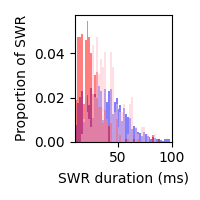

In [208]:
SWR = SWR.dropna(subset=['Assembly_Spatial_ID'])
SWR_unique = SWR.drop_duplicates(subset=['SWR_ID'])
CA1=SWR_unique[SWR_unique['SWRStartLocation']=='CA1']
CA1=CA1[CA1['GlobalSWR']=='Local']
RSC=SWR_unique[SWR_unique['SWRStartLocation']=='RSC']
RSC=RSC[RSC['GlobalSWR']=='Local']
CA1RSC=SWR_unique[SWR_unique['GlobalSWR']=='Global']

plt.close('all')
CA1['SWRDuration'].hist(bins=50, range=[10, 100], color='b', alpha=0.5, grid=False, density=True, figsize=(2,2))
RSC['SWRDuration'].hist(bins=50, range=[10, 100], color='r', alpha=0.5, grid=False, density=True, figsize=(2,2))
CA1RSC['SWRDuration'].hist(bins=50, range=[10, 100], color='pink', alpha=0.5, grid=False, density=True, figsize=(2,2))
plt.xlabel('SWR duration (ms)')
plt.ylabel('Proportion of SWR')
plt.xlim([10, 100])
print('Nb CA1 SWR =', len(CA1),', Nb RSC SWR =', len(RSC),', Nb CA1RSC SWR =', len(CA1RSC))
print(np.round(len(CA1RSC[CA1RSC['SWRStartLocation']=='RSC'])/len(CA1RSC)*100, 1), '% of Global SWR starts in the RSC')
plt.tight_layout()
plt.show()

Load PSTh & Select Coupling

In [233]:
Oscillations={'Spdl', 'SWR'}
Oscillations={'SWR'}

Data='Ca'
Coupling=''
save = 1

for Osc in Oscillations:
    if Osc == 'SWR':
        Ctx= {'CA1', 'RSC','CA1RSC'}
    elif Osc == 'Spdl': 
        Ctx= {'S1', 'PFC','S1PFC'}
    for ctx in Ctx:
        filename=f"{path5}/{Osc}_{Data}PSTH_{Coupling}{ctx}.pkl"
        with open(filename, 'rb') as pickle_file:
            locals()[f'{Osc}_{ctx}'] = dict(pickle.load(pickle_file))

Include CA1RSC SWR into CA1 SWR (optional)

In [ ]:
dicts = [SWR_CA1, SWR_CA1RSC]  # list of dicts
# all keys that appear in ANY dictionary
all_keys = set().union(*dicts)

result = {}
for k in all_keys:
    arrays = [d[k] for d in dicts if k in d]   # use only existing values
    result[k] = np.concatenate(arrays, axis=0)
SWR_CA1= result

OR gather Pre, Post, PrePostcoupled oscillations into Coupled

In [ ]:
Couplings={'PreCoupled', 'PrePostCoupled', 'PostCoupled'}
Coupling= 'Coupled'

Oscillations={'Spdl', 'SWR'}
Data='Ca'

for Osc in Oscillations:
    if Osc == 'SWR':
        Ctx= {'CA1', 'RSC','CA1RSC'}
    elif Osc == 'Spdl': 
        Ctx= {'S1', 'PFC','S1PFC'}
    for ctx in Ctx:        
        for coup in Couplings:
            filename=f"{path5}/{Osc}_{Data}PSTH_{coup}{ctx}.pkl"
            with open(filename, 'rb') as pickle_file:
                locals()[f'{Osc}_{ctx}_{coup}'] = pickle.load(pickle_file)
        dicts= [locals()[f'{Osc}_{ctx}_PreCoupled'], locals()[f'{Osc}_{ctx}_PrePostCoupled'], locals()[f'{Osc}_{ctx}_PostCoupled']]
        locals()[f'{Osc}_{ctx}'] = defaultdict(list)
        for d in dicts:
            for key, value in d.items():
                locals()[f'{Osc}_{ctx}'][key].extend(value)  # extend because values are lists of lists
        locals()[f'{Osc}_{ctx}'] = dict(locals()[f'{Osc}_{ctx}'])

#### Mean per ID

Per Neuron ID

In [ ]:
label_colors = {'PC': 'cyan', 'PC&HD': 'green', 'HD': 'blue', 'BodyMotion': 'orange', 'unclassified': 'grey', 'mix': 'purple'}
label_colors2 = {'BrC': "#8B6120FF", 'PC': "#AF72FFFF", 'BC': "#5869FFFF", 'RC': "#FF7979FF", 'RL':"#FF6FD4FD", 'YL': "#FFE96EFF"}

window = [-1, 1]  # from -10s to +10s around each event
bin_width = 1/20
bins = np.arange(window[0], window[1] + bin_width, bin_width)

for Osc in Oscillations:
    if Osc == 'SWR':
        Ctx= {'CA1', 'RSC','CA1RSC'}
    elif Osc == 'Spdl': 
        Ctx= {'S1', 'PFC','S1PFC'}
        
    fig = plt.figure(figsize=(10, 4))    
    subfigs = fig.subfigures(1, len(Ctx), wspace=0.07, hspace=0.1)

    print(Osc)

    for subplotnb, subfig in enumerate(subfigs.flat, start=1):
        ctx=list(Ctx)[subplotnb-1]  
        
        PSTH = locals()[f'{Osc}_{ctx}']
        PSTH_filt = {k: v for k, v in PSTH.items() if k in df_CellAss_ID['Assembly_ID'].values} #keep Cell assemblies with >=2 cells in it
        PSTH_filt_norm = {key: data - np.nanmean(data[:, :np.shape(data)[1] // 4], axis=1)[:, None] for key, data in PSTH_filt.items()}
        data = np.array([np.nanmean(PSTH_filt_norm[key], axis= 0) for key in PSTH_filt_norm.keys()])
        psth_df = pd.DataFrame(data.T, columns = list(PSTH_filt_norm.keys()))
        
                
        # identify cell identity
        psth_df = psth_df.T
        psth_df['Assembly_ID']=psth_df.index
        psth_df = pd.merge(psth_df, df_CellAss_ID[['Assembly_ID', 'Mice', 'Assembly_Neurons_ID']].drop_duplicates(), on='Assembly_ID', how='outer')
        psth_df["Assembly_Neurons_ID"] = psth_df["Assembly_Neurons_ID"].str.replace("_", "", regex=False)
        psth_df.index=  psth_df["Mice"] + "_" + psth_df["Assembly_ID"] + "_" + psth_df["Assembly_Neurons_ID"]
        psth_df = psth_df.drop(["Assembly_ID", "Assembly_Neurons_ID", "Mice"], axis=1)
        
        psth_df = psth_df.dropna(how='any') # remove cells not recorded during oscillations
        psth_df = psth_df[psth_df.index.str.split('_').str[-1] != 'unclassified'] if 'unclassified' not in label_colors.keys() else psth_df
        psth_df = psth_df[psth_df.index.str.split('_').str[-1] != 'nan']
        psth_df = psth_df[~psth_df.index.isna()]

        # normalize each row
        psth_df_n = psth_df.divide(psth_df.max(axis=1), axis='index') 
        psth_df_n = zscore(psth_df, axis=1)
        psth_df_n = psth_df_n.replace(np.nan, 0)
        
        # or do not normalize
        #psth_df_n = psth_df.replace(np.nan, 0)

        # sort by max activity position & sort by identity
        max_col_pos = psth_df_n.values.argmax(axis=1)
        psth_df_n['max_col_pos']= max_col_pos    
        order_map = {v: i for i, v in enumerate(label_colors.keys())}
        psth_df_n["neuronID"] =[str(idx).split('_')[-1] for idx in psth_df_n.index.tolist()]
        psth_df_n["neuronID"] = psth_df_n["neuronID"].map(order_map)
        df = psth_df_n.sort_values(["neuronID", "max_col_pos"]).drop(columns="max_col_pos").drop(columns="neuronID")


        gs = subfig.add_gridspec(nrows=2, ncols=3, height_ratios=[3, 1], width_ratios=[10, 0.5, 0.5],hspace=0.01, wspace=0.05)

        row_labels = df.index.str.split('_').str[-1]
        color_codes = [list(label_colors).index(lbl) for lbl in row_labels]
        color_array = np.array(color_codes).reshape(-1, 1)
        cmap = ListedColormap([label_colors[k] for k in label_colors])
        
        row_labels2 = df.index.str.split('_').str[0]
        color_codes2 = [list(label_colors2).index(lbl) for lbl in row_labels2]
        color_array2 = np.array(color_codes2).reshape(-1, 1)
        cmap2 = ListedColormap([label_colors2[k] for k in label_colors2])

        ax_heatmap = subfig.add_subplot(gs[0, 0])
        sns.heatmap(df, ax=ax_heatmap, cmap="viridis", cbar=False, cbar_kws={'location': 'top'}, yticklabels=False, vmin=0, vmax=2)
        ax_heatmap.set_yticklabels([]) 
        ax_heatmap.set_xticks([])
        ax_heatmap.set_ylabel(f" Cell assemblies")  
        ax_heatmap.collections[0].set_rasterized(True) if save else None

        ax_ann = subfig.add_subplot(gs[0, 1])
        sns.heatmap(color_array, ax=ax_ann, cmap=cmap, cbar=False, vmin=0, vmax=len(label_colors) - 1)
        ax_ann.set_xticks([])
        ax_ann.set_yticks([])
        ax_ann.tick_params(left=False, right=False)       

        ax_ann2 = subfig.add_subplot(gs[0, 2])
        sns.heatmap(color_array2, ax=ax_ann2, cmap=cmap2, cbar=False, vmin=0, vmax=len(label_colors2) - 1)
        ax_ann2.set_xticks([])
        ax_ann2.set_yticks([])
        ax_ann2.tick_params(left=False, right=False)             

        ax_bottom = subfig.add_subplot(gs[1, 0])  
        #ax_bottom.plot(time_bins, zscore(np.mean(df, axis=0)), color='black')
        time_bins = np.linspace(window[0], window[1], len(bins)-1)
        ax_bottom.axvline(x=0, color='lightgrey', linestyle='--', linewidth=1)
        for label in label_colors.keys():
            df_a = df[df.index.str.split('_').str[-1] == label]
            ax_bottom.plot(time_bins, zscore(np.mean(df_a, axis=0)), color=label_colors[label])
        ax_bottom.set_xlabel(f"Time from {Osc} (s)")
        ax_bottom.set_xlim(window[0], window[1])
        ax_bottom.set_ylim(-2, 5)

        subfig.suptitle(f'{Coupling} {ctx} {Osc} (n = {len(df)})')
        
    plt.tight_layout()
    plt.savefig(f'{Path(path5)}/AllCellAss_RSheatmap&traces_{Coupling}{Osc}.svg', format='svg', bbox_inches='tight', pad_inches=0, transparent=True) if save else None
    plt.show()

Per Spatial ID

SWR


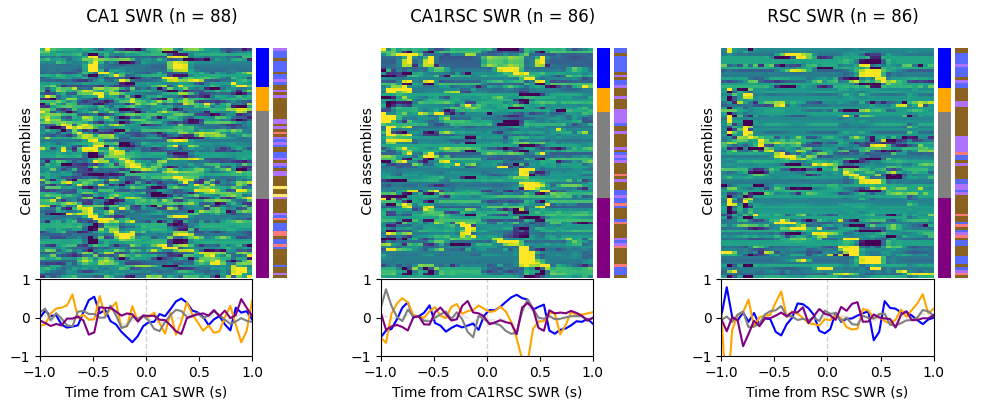

In [236]:
label_colors = {'Spatial': 'blue', 'NonSpatial': 'orange', 'unknown':'grey',  'mix': 'purple'}
label_colors2 = {'BrC': "#8B6120FF", 'PC': "#AF72FFFF", 'BC': "#5869FFFF", 'RC': "#FF7979FF", 'RL':"#FF6FD4FD", 'YL': "#FFE96EFF"}
#label_colors2 = {'Positively': 'green', 'Negatively': 'red', 'NotModulated': 'grey'}

window = [-1, 1]  # from -10s to +10s around each event
bin_width = 1/20
bins = np.arange(window[0], window[1] + bin_width, bin_width)

for Osc in Oscillations:
    if Osc == 'SWR':
        Ctx= {'CA1', 'RSC','CA1RSC'}
    elif Osc == 'Spdl': 
        Ctx= {'S1', 'PFC','S1PFC'}
        
    fig = plt.figure(figsize=(10, 4))    
    subfigs = fig.subfigures(1, len(Ctx), wspace=0.07, hspace=0)
    print(Osc)

    for subplotnb, subfig in enumerate(subfigs.flat, start=1):
        ctx=list(Ctx)[subplotnb-1]     
        
        PSTH = locals()[f'{Osc}_{ctx}']
        PSTH_filt = {k: v for k, v in PSTH.items() if k in df_CellAss_ID['Assembly_ID'].values}
        PSTH_filt_baseline = {key: data - np.nanmean(data[:, :data.shape[1] // 4], axis=1)[:, None] for key, data in PSTH_filt.items()}
        #PSTH_filt_baseline = PSTH_filt
        data = np.array([np.nanmean(PSTH_filt_baseline[key], axis= 0) for key in PSTH_filt_baseline.keys()])
        psth_df = pd.DataFrame(data.T, columns = list(PSTH_filt_baseline.keys()))
            
        # identify cell identity
        psth_df = psth_df.T
        psth_df['Assembly_ID']=psth_df.index
        psth_df = pd.merge(psth_df, df_CellAss_ID[['Assembly_ID', 'Mice', 'Assembly_Spatial_ID', 'Cells_in_Assembly']].drop_duplicates(subset=['Assembly_ID', 'Mice', 'Assembly_Spatial_ID']), on='Assembly_ID', how='outer')
        psth_df["Assembly_Spatial_ID"] = psth_df["Assembly_Spatial_ID"].str.replace("_", "", regex=False)
        psth_df.index=  psth_df["Mice"] + "_" + psth_df["Assembly_ID"] + "_" + psth_df["Assembly_Spatial_ID"] +  "_"  + psth_df['Cells_in_Assembly'].apply(lambda x: "-".join(map(str, x)))
        psth_df = psth_df.drop(["Assembly_ID", "Assembly_Spatial_ID", "Mice", "Cells_in_Assembly"], axis=1)
        
        psth_df = psth_df.dropna(how='any') # remove cells not recorded during oscillations
        psth_df = psth_df[psth_df.index.str.split('_').str[-2] != 'unclassified'] if 'unclassified' not in label_colors.keys() else psth_df
        psth_df = psth_df[psth_df.index.str.split('_').str[-2] != 'nan']
        psth_df = psth_df[~psth_df.index.isna()]

        # normalize each row
        #psth_df_n = psth_df.divide(psth_df.max(axis=1), axis='index') 
        psth_df_n = zscore(psth_df, axis=1)
        psth_df_n = psth_df_n.replace(np.nan, 0)
        
        # or do not normalize
        #psth_df_n = psth_df.replace(np.nan, 0)

        # sort by max activity position & sort by identity
        max_col_pos = psth_df_n.values.argmax(axis=1)
        psth_df_n['max_col_pos']= max_col_pos    
        order_map = {v: i for i, v in enumerate(label_colors.keys())}
        psth_df_n["neuronID"] =[str(idx).split('_')[-2] for idx in psth_df_n.index.tolist()]
        psth_df_n["neuronID"] = psth_df_n["neuronID"].map(order_map)
        df = psth_df_n.sort_values(["neuronID", "max_col_pos"]).drop(columns="max_col_pos").drop(columns="neuronID")
        #df = psth_df_n.sort_values(["max_col_pos"]).drop(columns="max_col_pos").drop(columns="neuronID")

        if len(df)>0:

            gs = subfig.add_gridspec(nrows=2, ncols=3, height_ratios=[3, 1],   width_ratios=[8, 0.5, 0.5], hspace=0.01, wspace=0.05 )

            row_labels = df.index.str.split('_').str[-2]
            color_codes = [list(label_colors).index(lbl) for lbl in row_labels]
            color_array = np.array(color_codes).reshape(-1, 1)
            cmap1 = ListedColormap([label_colors[k] for k in label_colors])
            
            row_labels2 = df.index.str.split('_').str[0]
            color_codes2 = [list(label_colors2).index(lbl) for lbl in row_labels2]
            color_array2 = np.array(color_codes2).reshape(-1, 1)
            cmap2 = ListedColormap([label_colors2[k] for k in label_colors2])

            ax_heatmap = subfig.add_subplot(gs[0, 0])
            sns.heatmap(df, ax=ax_heatmap, cmap="viridis", cbar=False, cbar_kws={'location': 'top'}, yticklabels=False, vmin=-2, vmax=2)
            ax_heatmap.set_yticklabels([]) 
            ax_heatmap.set_xticks([])
            ax_heatmap.set_ylabel(f" Cell assemblies")  
            #ax_heatmap.set_yticks(np.arange(len(df.index)))
            #ax_heatmap.set_yticklabels(df.index.str.split('_').str[-1], fontsize = 5.5)
            ax_heatmap.collections[0].set_rasterized(True) if save else None
            
            ax_ann = subfig.add_subplot(gs[0, 1])
            sns.heatmap(color_array, ax=ax_ann, cmap=cmap1, cbar=False, vmin=0, vmax=len(label_colors) - 1)
            ax_ann.set_xticks([])
            ax_ann.set_yticks([])
            ax_ann.tick_params(left=False, right=False)       

            ax_ann2 = subfig.add_subplot(gs[0, 2])
            sns.heatmap(color_array2, ax=ax_ann2, cmap=cmap2, cbar=False, vmin=0, vmax=len(label_colors2) - 1)
            ax_ann2.set_xticks([])
            ax_ann2.set_yticks([])
            ax_ann2.tick_params(left=False, right=False) 

            time_bins = np.linspace(window[0], window[1], len(bins)-1)
            ax_bottom = subfig.add_subplot(gs[1, 0])  # span both columns
            ax_bottom.plot(time_bins, np.mean(df, axis=0), color='black', alpha=0.1, linestyle='--')
            ax_bottom.axvline(x=0, color='lightgrey', linestyle='--', linewidth=1)
            for label in label_colors.keys():
                df_a = df[df.index.str.split('_').str[-2] == label]
                ax_bottom.plot(time_bins, np.mean(df_a, axis=0), color=label_colors[label])
            ax_bottom.set_xlabel(f"Time from {ctx} {Osc} (s)")
            ax_bottom.set_xlim(window[0], window[1])
            ax_bottom.set_ylim(-1, 1)

            subfig.suptitle(f'{Coupling} {ctx} {Osc} (n = {len(df)})')
    plt.tight_layout()
    plt.savefig(f'{Path(path5)}/AllCellAss_Spatial_RSheatmap&traces_{Coupling}{Osc}.svg', format='svg', bbox_inches='tight', pad_inches=0, transparent=True) if save else None
    plt.show()

#### Example from one cell assembly

In [ ]:
cell_ass='13_14_28_CellAss1'
save = 1

In [ ]:
def process_and_plot(data, ax, vmin=-5, vmax=5):
    #data1=data.iloc[:, data.shape[1] // 10 *4  : data.shape[1] // 10 * 6]
    data1=data[:, np.shape(data)[1] // 10 *4  : np.shape(data)[1] // 10 * 6]
    n_cols = np.shape(data1)[1] // 4  # Floor division to get the number of columns in 1/4th
    baseline_columns = data1[:, :n_cols]  # Select the first 'n_cols' columns
    mean_baseline = np.nanmean(baseline_columns,axis=1)
    data2 = data1-mean_baseline[:, np.newaxis]
    sns.heatmap(data, ax=ax, cmap='viridis', xticklabels=False, yticklabels=False, vmin=vmin, vmax=vmax)
    #sns.heatmap(data2, ax=ax, cmap='viridis', xticklabels=False, yticklabels=False, vmin=vmin, vmax=vmax)

plt.close()

for Osc in Oscillations:
    if Osc == 'SWR':
        Ctx= {'CA1', 'RSC','CA1RSC'}
    elif Osc == 'Spdl': 
        Ctx= {'S1', 'PFC','S1PFC'}
    fig, axes = plt.subplots(1, len(Ctx), figsize=(6, 3))
    # Check if subplots are correctly created
    for subplotnb, ctx in enumerate(Ctx):
        PSTH = locals()[f'{Osc}_{ctx}']
        axes[subplotnb].set_title(f'{Osc}_{ctx}', size=10)
        if PSTH != {}: 
            if cell_ass in  PSTH:
                process_and_plot(np.array(PSTH[cell_ass]), axes[subplotnb])
    fig.suptitle(f"{cell_ass} ({df_CellAss_ID[df_CellAss_ID['Assembly_ID']==cell_ass]['Assembly_Neurons_ID'].unique().tolist()[0]}, {df_CellAss_ID[df_CellAss_ID['Assembly_ID']==cell_ass]['Assembly_Spatial_ID'].unique().tolist()[0]})")    
    plt.tight_layout()
    plt.savefig(f'{Path(path5)}/{cell_ass}_heatmap_{Osc}.svg', format='svg', bbox_inches='tight', pad_inches=0, transparent=True) if save else None
    plt.show()


In [ ]:
plt.close()

#cmap = sns.light_palette("#008B8B", as_cmap=True)
cmap = sns.light_palette("black", as_cmap=True)

def plot_lines(data, ax, title, title_color='black', cmap=cmap):
    data1=data[:, data.shape[1] // 10 *4  : data.shape[1] // 10 * 6]
    n_cols = np.shape(data1)[1]// 4  # Floor division to get the number of columns in 1/4th
    baseline_columns = data1[:, :n_cols]   # Select the first 'n_cols' columns
    mean_baseline = np.nanmean(baseline_columns,axis=1)
    data2 = data1-mean_baseline[:, np.newaxis]
    ax.plot(np.nanmean(data2, axis=0), color=title_color, linewidth=2)
    ax.set_ylim(-1, 2)    
    ax.set_title(title, fontsize=10, color=title_color, pad=10)  # Added padding for the title
    ax.axis('off')  # Hide axis lines and labels

for Osc in Oscillations:
    if Osc == 'SWR':
        Ctx= {'CA1', 'RSC','CA1RSC'}
    elif Osc == 'Spdl': 
        Ctx= {'S1', 'PFC','S1PFC'}
    fig, axes = plt.subplots(1, len(Ctx), figsize=(6, 2))  # Increased figure size for better readability

    colortitle= ['orange','rebeccapurple','mediumseagreen',] #if Osc =='SPDL' else ['orange','rebeccapurple','mediumseagreen',]
    for subplotnb, ctx in enumerate(Ctx):
        PSTH = locals()[f'{Osc}_{ctx}']
        if cell_ass in PSTH: 
            data = PSTH[cell_ass][::]*1   #[::2] Taking every other row
            plot_lines(np.array(data), axes[subplotnb], f'{ctx}', title_color=colortitle[subplotnb])

    fig.suptitle(f"{cell_ass} ({df_CellAss_ID[df_CellAss_ID['Assembly_ID']==cell_ass]['Assembly_Neurons_ID'].unique().tolist()[0]}, {df_CellAss_ID[df_CellAss_ID['Assembly_ID']==cell_ass]['Assembly_Spatial_ID'].unique().tolist()[0]})")    

    plt.tight_layout()
    plt.savefig(f'{Path(path5)}/{cell_ass}_AvgRSTraces_{Osc}.svg', format='svg', bbox_inches='tight', pad_inches=0, transparent=True) if save else None
    plt.show()
